In [1]:
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from time import time
from functools import reduce
from collections import Counter
import matplotlib.pyplot as plt
import datasets
from datasets import load_dataset, get_dataset_split_names

In [23]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
ls ../databases/

books.db


In [27]:
conn = sqlite3.connect("../databases/books.db")
curs = conn.cursor()

In [40]:
curs.execute("SELECT * FROM authors")
all_authors = curs.fetchall()

curs.execute("SELECT * FROM books")
all_books = curs.fetchall()

curs.execute("SELECT * FROM text_files")
book_contents = curs.fetchall()

In [50]:
book_contents[-20]

(10151,
 'txt',
 '\n\n\n\n\n\n\n\nIII\n\n\n\n\n\n\n\n\n\n\n\nHis purpose had been to see Chad the next day, and he had prefigured\n\n\n\nseeing him by an early call; having in general never stood on ceremony\n\n\n\nin respect to visits at the Boulevard Malesherbes.  It had been\n\n\n\nmore often natural for him to go there than for Chad to come to the\n\n\n\nsmall hotel, the attractions of which were scant; yet it nevertheless,\n\n\n\njust now, at the eleventh hour, did suggest itself to Strether to begin\n\n\n\nby giving the young man a chance.  It struck him that, in the\n\n\n\ninevitable course, Chad would be "round," as Waymarsh used to say--\n\n\n\nWaymarsh who already, somehow, seemed long ago.  He hadn\'t come the\n\n\n\nday before, because it had been arranged between them that Madame de Vionnet\n\n\n\nshould see their friend first; but now that this passage had taken place\n\n\n\nhe would present himself, and their friend wouldn\'t have long to wait.\n\n\n\nStrether assumed, h

In [10]:
curs.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = curs.fetchall()

In [11]:
tables

[('book_original',), ('text_files',), ('book_file',), ('authors',), ('books',)]

In [48]:
len(all_books)

1087

In [246]:
dataset["train"][10]["metadata"]

{'license': 'Public Domain',
 'language': 'en',
 'url': 'https://www.gutenberg.org/ebooks/10006.txt.utf-8',
 'title': 'La Fiammetta'}

In [250]:
df.loc[11]

Text#                                                         12
Type                                                        Text
Issued                                                2008-06-25
Title                                  Through the Looking-Glass
Language                                                      en
Authors                                Carroll, Lewis, 1832-1898
Subjects       Fantasy fiction; Children's stories; Imaginary...
LoCC                                                      PR; PZ
Bookshelves    Children's Literature; Best Books Ever Listing...
Name: 11, dtype: object

In [2]:
from datasets import load_dataset

In [56]:
dataset = load_dataset("common-pile/project_gutenberg")

README.md:   0%|          | 0.00/2.67k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

v0/documents/00000_pg.jsonl.gz:   0%|          | 0.00/350M [00:00<?, ?B/s]

v0/documents/00001_pg.jsonl.gz:   0%|          | 0.00/351M [00:00<?, ?B/s]

v0/documents/00002_pg.jsonl.gz:   0%|          | 0.00/347M [00:00<?, ?B/s]

...

v0/documents/00027_pg.jsonl.gz:   0%|          | 0.00/339M [00:00<?, ?B/s]

v0/documents/00028_pg.jsonl.gz:   0%|          | 0.00/346M [00:00<?, ?B/s]

v0/documents/00029_pg.jsonl.gz:   0%|          | 0.00/111M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/52 [00:00<?, ?it/s]

In [87]:
dataset["train"]["metadata"][-10]

{'license': 'Public Domain',
 'language': 'en',
 'url': 'https://www.gutenberg.org/ebooks/9990.txt.utf-8',
 'title': 'Brave and Bold; Or, The Fortunes of Robert Rushton'}

In [104]:
"chapter" in dataset["train"]["text"][10]

False

In [103]:
"CHAPTER" in dataset["train"]["text"][10]

False

In [102]:
"Chapter" in dataset["train"]["text"][10]

True

In [113]:
from tqdm import tqdm
import numpy as np

In [121]:
r = []
for i, t in tqdm(enumerate(dataset["train"]["text"])):
    r.append("chapter" in t or "Chapter" in t or "CHAPTER" in t or "section" in t or "Section" in t or "SECTION" in t)

71810it [02:20, 509.75it/s]


In [122]:
np.mean(r)

0.6545467205124634

In [116]:
language = [ metadata["language"] for metadata in dataset["train"]["metadata"]]

In [117]:
from collections import Counter

In [118]:
Counter(language)

Counter({'en': 57641,
         'fr': 3688,
         'fi': 2909,
         'de': 2145,
         'nl': 999,
         'it': 994,
         'es': 814,
         'pt': 638,
         'hu': 531,
         'zh': 435,
         'sv': 228,
         'el': 215,
         'eo': 111,
         'la': 103,
         'da': 78,
         'tl': 57,
         'ca': 44,
         'pl': 29,
         'no': 21,
         'ja': 21,
         'cy': 15,
         'af': 15,
         'cs': 7,
         'is': 7,
         'ru': 6,
         'te': 6,
         'bg': 5,
         'he': 4,
         'fy': 4,
         'ro': 4,
         'sr': 3,
         'enm': 3,
         'gl': 3,
         'ilo': 2,
         'ga': 2,
         'ceb': 2,
         'arp': 2,
         'gla': 2,
         'sl': 2,
         'myn': 1,
         'oc': 1,
         'nap': 1,
         'nah': 1,
         'mi': 1,
         'br': 1,
         'iu': 1,
         'fur': 1,
         'rmq': 1,
         'oji': 1,
         'ar': 1,
         'et': 1,
         'fa': 1,
         'bo

In [119]:
len(language)

71810

In [120]:
57641/71810

0.8026876479598941

In [123]:
pip install gutenberg

Defaulting to user installation because normal site-packages is not writeable
  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [4 lines of output]
      /private/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/pip-install-0mjcabe0/bsddb3_234378491d944f9e83a72d765bcc864d/setup3.py:94: SyntaxWarning: invalid escape sequence '\s'
        _ver_re = re.compile('^#\s*define\s+PY_BSDDB_VERSION\s+"(\d+\.\d+\.\d+.*)"')
      Can't find a local Berkeley DB installation.
      (suggestion: try the --berkeley-db=/path/to/bsddb option)
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Note: you may need to restart the k

In [124]:
import pandas as pd
df = pd.read_csv("https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv.gz", compression="gzip")

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78637 entries, 0 to 78636
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Text#        78637 non-null  int64 
 1   Type         78637 non-null  object
 2   Issued       78637 non-null  object
 3   Title        78637 non-null  object
 4   Language     78637 non-null  object
 5   Authors      78472 non-null  object
 6   Subjects     78595 non-null  object
 7   LoCC         78384 non-null  object
 8   Bookshelves  75696 non-null  object
dtypes: int64(1), object(8)
memory usage: 5.4+ MB


There is no duplicates

In [178]:
df.duplicated().mean()

0.0

Here are the available columns:

In [179]:
df.columns

Index(['Text#', 'Type', 'Issued', 'Title', 'Language', 'Authors', 'Subjects',
       'LoCC', 'Bookshelves'],
      dtype='object')

There are books with two languages, e.g english and latin "en; la".

In [180]:
df.Language.unique()

array(['en', 'la', 'es', 'de; en', 'de; la', 'fr', 'it', 'en; fr', 'ja',
       'de', 'en; zh', 'sv', 'da', 'cy', 'bg', 'pt', 'nl', 'el', 'zh',
       'he', 'en; es', 'ru', 'en; hu', 'en; ko', 'pl', 'fi', 'en; la',
       'en; eo', 'en; enm', 'eo', 'en; sv', 'sa', 'en; ang', 'cy; en',
       'en; ale', 'yi', 'lt', 'es; nai', 'sr', 'no', 'ca; de', 'ro',
       'en; nah', 'en; kha', 'cs', 'tl', 'en; it', 'ca', 'is', 'de; fr',
       'myn', 'fr; nai', 'es; tl', 'ilo', 'ia', 'en; es; tl', 'ga',
       'es; ilo', 'fur', 'af', 'en; kld', 'enm', 'oc', 'fr; it', 'nap',
       'hu', 'la; nl', 'fy', 'fr; la', 'en; myn', 'ceb', 'gl', 'nah',
       'mi', 'en; nav', 'br', 'arp', 'cs; eo', 'en; es; fr', 'iu',
       'es; bgs', 'fr; pl', 'pl; csb', 'en; pt', 'gla', 'da; en', 'rmq',
       'fy; nl', 'fr; el', 'la; el', 'en; nai', 'fr; pt', 'de; fur', 'sl',
       'de; nl', 'fr; oc', 'te', 'oji', 'en; el', 'en; fy', 'fr; nl',
       'en; ceb', 'en; grc', 'en; mi', 'ar', 'et', 'de; ang', 'fa', 'sco',
  

We only want to keep the texts that are english:

In [181]:
english_texts = df.loc[df.Language.str.contains("en", na=False)]

In [182]:
english_texts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62509 entries, 0 to 78636
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Text#        62509 non-null  int64 
 1   Type         62509 non-null  object
 2   Issued       62509 non-null  object
 3   Title        62509 non-null  object
 4   Language     62509 non-null  object
 5   Authors      62360 non-null  object
 6   Subjects     62501 non-null  object
 7   LoCC         62301 non-null  object
 8   Bookshelves  60183 non-null  object
dtypes: int64(1), object(8)
memory usage: 4.8+ MB


In [183]:
english_texts.shape

(62509, 9)

Among all the English texts, the vast majority is English only. We can drop the rest.

In [184]:
print(english_texts.Language.value_counts())
print(english_texts.Language.value_counts()/62509)

Language
en            62324
de; en           32
en; la           30
en; fr           26
en; eo           19
en; es           19
en; zh            8
en; it            4
en; grc           3
en; enm           3
en; ang           3
cy; en            3
en; nav           3
enm               3
en; brx           2
en; pt            2
en; es; fr        2
en; gla           2
en; es; tl        2
en; nah           2
en; ceb           1
en; hai           1
bo; en            1
en; la; el        1
en; ga            1
en; hu            1
en; mi            1
en; ko            1
en; fy            1
en; kha           1
en; el            1
en; nai           1
da; en            1
en; sv            1
en; ale           1
en; myn           1
en; kld           1
Name: count, dtype: int64
Language
en            0.997040
de; en        0.000512
en; la        0.000480
en; fr        0.000416
en; eo        0.000304
en; es        0.000304
en; zh        0.000128
en; it        0.000064
en; grc       0.000048
en; enm  

In [185]:
english_texts = english_texts.loc[(english_texts.Language == "en")]
print(english_texts.info())

<class 'pandas.core.frame.DataFrame'>
Index: 62324 entries, 0 to 78636
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Text#        62324 non-null  int64 
 1   Type         62324 non-null  object
 2   Issued       62324 non-null  object
 3   Title        62324 non-null  object
 4   Language     62324 non-null  object
 5   Authors      62176 non-null  object
 6   Subjects     62316 non-null  object
 7   LoCC         62116 non-null  object
 8   Bookshelves  60002 non-null  object
dtypes: int64(1), object(8)
memory usage: 4.8+ MB
None


In [186]:
english_texts.Language.value_counts()

Language
en    62324
Name: count, dtype: int64

We now have all the entries that are in English only. How many are texts ?

In [190]:
english_texts["Type"].value_counts(dropna=False)

Type
Text           61139
Sound           1048
Dataset           89
Image             33
MovingImage        8
Collection         4
StillImage         3
Name: count, dtype: int64

Let's keep only the texts:

In [191]:
english_texts = english_texts.loc[english_texts.Type == "Text"]

In [192]:
english_texts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61139 entries, 0 to 78636
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Text#        61139 non-null  int64 
 1   Type         61139 non-null  object
 2   Issued       61139 non-null  object
 3   Title        61139 non-null  object
 4   Language     61139 non-null  object
 5   Authors      61023 non-null  object
 6   Subjects     61134 non-null  object
 7   LoCC         60934 non-null  object
 8   Bookshelves  59743 non-null  object
dtypes: int64(1), object(8)
memory usage: 4.7+ MB


Let's keep only the ones that have a Bookshelf:

In [223]:
english_texts.Bookshelves.isna().mean()

0.022833216114100656

In [224]:
english_texts = english_texts.loc[english_texts.Bookshelves.isna() == False]

Next, we are going to remove anything that is poetry, science, technology, engineering, medicine, economics, law, business, managements

In [214]:
mask_novels = english_texts["Bookshelves"].str.contains("Novels").values

In [217]:
non_novels = english_texts["Bookshelves"][mask_novels == False]

In [220]:
non_novel

0        Politics; American Revolutionary War; United S...
1        Politics; American Revolutionary War; United S...
2        Category: Essays, Letters & Speeches; Category...
3        US Civil War; Category: Essays, Letters & Spee...
4        United States; Politics; American Revolutionar...
                               ...                        
76922    Category: History - European; Category: Histor...
76925    Category: Biographies; Category: Philosophy & ...
76930    Category: Biographies; Category: Travel Writin...
76932    Category: Science - Chemistry/Biochemistry; Ca...
78326    Women in Science, Technology, Engineering, and...
Name: Bookshelves, Length: 39349, dtype: object

In [156]:
sum(english_texts.Language.value_counts()/78637)

0.7949057059653853

In [164]:
sum(english_texts.Language.isna())

16128

In [166]:
t= df[df["Language"].str.contains("en", na=False)]

In [167]:
t.shape

(62509, 9)

In [232]:
dataset["train"][77109]

IndexError: Invalid key: 77109 is out of bounds for size 71810

In [229]:
english_texts

,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
0,1,Text,1971-12-01,The Declaration of Independence of the United ...,en,"Jefferson, Thomas, 1743-1826","United States -- History -- Revolution, 1775-1...",E201; JK,Politics; American Revolutionary War; United S...
1,2,Text,1972-12-01,The United States Bill of Rights\r\nThe Ten Or...,en,United States,Civil rights -- United States -- Sources; Unit...,JK; KF,Politics; American Revolutionary War; United S...
2,3,Text,1973-11-01,John F. Kennedy's Inaugural Address,en,"Kennedy, John F. (John Fitzgerald), 1917-1963",United States -- Foreign relations -- 1961-196...,E838,"Category: Essays, Letters & Speeches; Category..."
3,4,Text,1973-11-01,Lincoln's Gettysburg Address\r\nGiven November...,en,"Lincoln, Abraham, 1809-1865",Consecration of cemeteries -- Pennsylvania -- ...,E456,"US Civil War; Category: Essays, Letters & Spee..."
4,5,Text,1975-12-01,The United States Constitution,en,United States,United States -- Politics and government -- 17...,JK; KF,United States; Politics; American Revolutionar...
...,...,...,...,...,...,...,...,...,...
76926,77109,Text,2025-10-22,A journey to the world under-ground,en,"Holberg, Ludvig, 1684-1754","Voyages, Imaginary -- Early works to 1800; Uto...",PT,Category: Science-Fiction & Fantasy; Category:...
76928,77111,Text,2025-10-22,The mother,en,"Deledda, Grazia, 1871-1936; Steegmann, Mary G....",Italy -- Fiction; Mothers and sons -- Fiction;...,PQ,Category: Novels; Category: Classics of Litera...
76930,77113,Text,2025-10-23,"The autobiography of Sir Henry Morton Stanley,...",en,"Stanley, Henry M. (Henry Morton), 1841-1904; S...","Stanley, Henry M. (Henry Morton), 1841-1904; E...",DT,Category: Biographies; Category: Travel Writin...
76932,77115,Text,2025-10-23,An ice cream laboratory guide,en,"Fisk, W. W. (Walter Warner), 1888-1979; Ellenb...","Ice cream, ices, etc.",TX,Category: Science - Chemistry/Biochemistry; Ca...


In [ ]:
sedthh/gutenberg_english

In [8]:
dataset = load_dataset("sedthh/gutenberg_english")

Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/29 [00:00<?, ?it/s]

In [9]:
eval(dataset["train"]["METADATA"][0])

{'language': 'en',
 'text_id': 2,
 'title': 'The United States Bill of Rights\r\nThe Ten Original Amendments to the Constitution of the United States',
 'issued': '1972-12-01 00:00:00',
 'authors': 'United States',
 'subjects': 'Civil rights -- United States -- Sources; United States. Constitution. 1st-10th Amendments',
 'locc': 'JK; KF',
 'bookshelves': 'Politics; American Revolutionary War; United States Law'}

In [10]:
catalog = pd.read_csv("https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv.gz", compression="gzip")
metadata = pd.DataFrame.from_dict([eval(m) for m in dataset["train"]["METADATA"]])
merged_catalog_meta_data = pd.merge(catalog, metadata, how="inner", left_on="Text#", right_on="text_id")
merged_catalog_meta_data = merged_catalog_meta_data[["Language", "Title", "Authors", "Subjects", "text_id", "Bookshelves"]]

In [14]:
merged_catalog_meta_data.Language.value_counts(dropna=True)
merged_catalog_meta_data = merged_catalog_meta_data.loc[merged_catalog_meta_data.Language == "en"]

Only a small percentage of books do not have any bookshelf. We can remove them.

In [16]:
merged_catalog_meta_data = merged_catalog_meta_data[merged_catalog_meta_data.Bookshelves.isna() == False]

In [183]:
def get_bookshelves(bookshelf):
    """
    Gets all the bookshelf for a book
    """
    splitted_result = re.split(r"[,;&]", bookshelf.replace("Category: ", "").lower().replace("-", "").replace(" ", ""))
    return splitted_result if type(splitted_result) == list else [splitted_result]

In [18]:
merged_catalog_meta_data.Bookshelves_bag_of_words = merged_catalog_meta_data.Bookshelves.apply(get_bookshelves)
bag_of_words = merged_catalog_meta_data.Bookshelves_bag_of_words.sum()
merged_catalog_meta_data.Bookshelves_bag_of_words
Counter(bag_of_words)
genre_to_keep = set(['novels',
         'britishliterature',
         'adventure',
         'americanliterature',
         'children',
         'youngadultreading',
         'sciencefiction',
         'biographies',
         'historyamerican',
         'historymodern(1750+)', 
         'fantasy',
         'shortstories',
         'historicalnovels',
         'historybritish',
         'travelwriting',
         'historywarfare',
         'historyother',
         'folklore',
         'mythology',
         'legends', 
         'historyeuropean', 
         'romance',
         'crime',
         'thrillersandmystery',
         'historyearlymodern(c.14501750)',
         'frenchliterature',
         'classicsofliterature'])

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93939/1562579686.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  merged_catalog_meta_data.Bookshelves_bag_of_words = merged_catalog_meta_data.Bookshelves.apply(get_bookshelves)


In [19]:
bag_of_words = merged_catalog_meta_data.Bookshelves_bag_of_words.sum()

In [20]:
merged_catalog_meta_data.Bookshelves_bag_of_words

0        [politics, americanrevolutionarywar, unitedsta...
1        [essays, letters, speeches, historyamerican, p...
2        [uscivilwar, essays, letters, speeches, histor...
3        [unitedstates, politics, americanrevolutionary...
4        [americanrevolutionarywar, essays, letters, sp...
                               ...                        
48208    [crime, thrillersandmystery, historymodern(175...
48209                                    [historyamerican]
48210                         [novels, oldage, theelderly]
48211                 [historyother, historymodern(1750+)]
48212            [howto..., politics, teaching, education]
Name: Bookshelves, Length: 48191, dtype: object

In [22]:
Counter(bag_of_words)

Counter({'novels': 14709,
         'britishliterature': 7372,
         'adventure': 6147,
         'americanliterature': 6059,
         'children': 5366,
         'youngadultreading': 5366,
         'sciencefiction': 4624,
         'biographies': 4137,
         'historyamerican': 4119,
         'historymodern(1750+)': 4109,
         'essays': 3630,
         'letters': 3630,
         'speeches': 3630,
         'humour': 3494,
         'fantasy': 3437,
         'shortstories': 3018,
         'historicalnovels': 3008,
         'poetry': 2996,
         'religion/spirituality': 2630,
         'historybritish': 2628,
         'travelwriting': 2523,
         'historywarfare': 2377,
         'historyother': 2341,
         'folklore': 2090,
         'mythology': 2055,
         'legends': 2041,
         'philosophy': 2039,
         'historyeuropean': 2005,
         'ethics': 1960,
         'howto...': 1891,
         'romance': 1722,
         'nature/gardening/animals': 1604,
         'crime': 15

In [23]:
genre_to_keep = set(['novels',
         'britishliterature',
         'adventure',
         'americanliterature',
         'children',
         'youngadultreading',
         'sciencefiction',
         'biographies',
         'historyamerican',
         'historymodern(1750+)', 
         'fantasy',
         'shortstories',
         'historicalnovels',
         'historybritish',
         'travelwriting',
         'historywarfare',
         'historyother',
         'folklore',
         'mythology',
         'legends', 
         'historyeuropean', 
         'romance',
         'crime',
         'thrillersandmystery',
         'historyearlymodern(c.14501750)',
         'frenchliterature',
         'classicsofliterature'])

In [24]:
def keep_on_genre(l, to_keep):
    """
    Check if the book is at least in one of the genre we want to keep
    """
    return set(l).intersection(to_keep) != set()

In [25]:
mask_genres = merged_catalog_meta_data.Bookshelves_bag_of_words.apply(keep_on_genre, args=(genre_to_keep, ))
kept_books = merged_catalog_meta_data[mask_genres]

In [26]:
kept_books.shape[0]/merged_catalog_meta_data.shape[0]

0.8106492913614576

In [27]:
Counter(dataset["train"]["SOURCE"])

Counter({'gutenberg': 48284})

In [29]:
kept_books

,Language,Title,Authors,Subjects,text_id,Bookshelves
0,en,The United States Bill of Rights\r\nThe Ten Or...,United States,Civil rights -- United States -- Sources; Unit...,2,Politics; American Revolutionary War; United S...
1,en,John F. Kennedy's Inaugural Address,"Kennedy, John F. (John Fitzgerald), 1917-1963",United States -- Foreign relations -- 1961-196...,3,"Category: Essays, Letters & Speeches; Category..."
2,en,Lincoln's Gettysburg Address\r\nGiven November...,"Lincoln, Abraham, 1809-1865",Consecration of cemeteries -- Pennsylvania -- ...,4,"US Civil War; Category: Essays, Letters & Spee..."
3,en,The United States Constitution,United States,United States -- Politics and government -- 17...,5,United States; Politics; American Revolutionar...
4,en,Give Me Liberty or Give Me Death,"Henry, Patrick, 1736-1799","Speeches, addresses, etc., American; United St...",6,"American Revolutionary War; Category: Essays, ..."
...,...,...,...,...,...,...
48207,en,"The Cameron pride; or, purified by suffering","Holmes, Mary Jane, 1825-1907",American fiction -- 19th century,69954,Category: Novels; Category: American Literature
48208,en,Was it a ghost? The murders in Bussey's wood,"Brent, Henry Johnson, 1811-1880",Ghosts; Murder -- Massachusetts -- Boston; Joy...,69955,"Category: Crime, Thrillers and Mystery; Catego..."
48209,en,Daily stories of Pennsylvania,"Godcharles, Frederic Antes, 1872-1944",Pennsylvania -- Biography; Pennsylvania -- His...,69956,Category: History - American
48210,en,Finding youth,"Andrews, Gertrude Nelson",Old age,69957,Category: Novels; Category: Old Age & the Elderly


In [30]:
kept_books.shape[0]/merged_catalog_meta_data.shape[0]
kept_books.text_id.duplicated().sum()

0

In [31]:
mask_content = metadata.text_id.apply(lambda x: x in kept_books.text_id.values)
mask_content.mean()
kept_indices = np.where(mask_content == True)

In [32]:
mask_content.mean()

0.809087896611714

In [33]:
kept_books.shape[0]/metadata.shape[0]

0.809087896611714

In [34]:
kept_indices[0]

NameError: name 'kept_indices' is not defined

In [36]:
kept_indices = np.where(mask_content == True)

In [44]:
len(kept_indices[0])

39066

In [42]:
len(dataset["train"])

48284

In [132]:
%time
kept_content = dataset["train"]["TEXT"][kept_indices[0]]

CPU times: user 9 μs, sys: 32 μs, total: 41 μs
Wall time: 66 μs


In [133]:
len(kept_content)

39066

In [85]:
processed_text =" ".join(kept_content[2].replace("\r\n", "\n").split("\n\n")).split("\n")

In [86]:
processed_text

["Lincoln's Gettysburg Address,given November 19, 1863 on the battlefield near Gettysburg, Pennsylvania, USA Four score and seven years ago, our fathers brought forth upon this continent a new nation:  conceived in liberty, and dedicated to the proposition that all men are created equal.",
 'Now we are engaged in a great civil war ... testing whether that nation, or any nation so conceived and so dedicated ... can long endure.  We are met on a great battlefield of that war.',
 'We have come to dedicate a portion of that field as a final resting place for those who here gave their lives that this nation might live. It is altogether fitting and proper that we should do this.',
 'But, in a larger sense, we cannot dedicate ... we cannot consecrate ... we cannot hallow this ground.  The brave men, living and dead, who struggled here have consecrated it, far above our poor power to add or detract.  The world will little note, nor long remember, what we say here, but it can never forget what 

In [135]:
from tqdm import tqdm

In [127]:
def chunk_in_paragraph(content, n_words, threshold=30):
    """
    Chunks a book into paragraphs.
    arguments:
    content -- content of the book as a str.
    n_words -- list of lists, containing the number of words for each paragraph.
    keyword arguments:
    threshold -- number of words under which we discard the paragraph.
    """
    paragraphs = " ".join(content.replace("\r\n", "\n").replace("\xa0", "").split("\n\n")).split("\n")
    filtered_paragraphs = []
    n_words = []
    for p in paragraphs:
        if len(p) > threshold:
            filtered_paragraphs.append(p)
            n_words.append(len(p.split(" ")))
            
    return paragraphs, n_words


def compute_num_words(content):
    """
    Chunks a book into paragraphs
    arguments:
    content -- content of the book as a str
    """
    paragraphs = " ".join(content.replace("\r\n", "\n").replace("\xa0", "").split("\n\n")).split("\n")
    n_words = [len(text.split(" ")) for text in paragraphs]
    return n_words

In [136]:
all_num_words = []
for l in tqdm(range(len(kept_content))):
    content = kept_content[l]
    n_words = compute_num_words(content)
    all_num_words.append(n_words)
    
all_length = np.array([l for t in all_num_words for l in t])
mean_length = np.array([np.mean(t) for t in all_num_words])
median_length = np.array([np.median(t) for t in all_num_words])
max_length = np.array([np.max(t) for t in all_num_words])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39066/39066 [14:48<00:00, 43.98it/s]


We have a total of 64 millions paragraphs.

In [141]:
len(all_length)/1e6

64.355144

Most paragraphs are between 1 and 100 words.

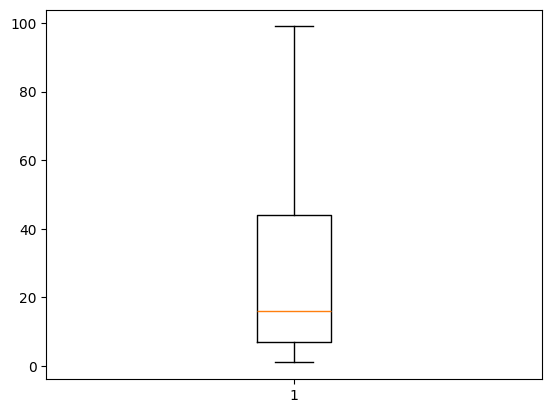

In [145]:
plt.boxplot(all_length, showfliers=False)
plt.show()

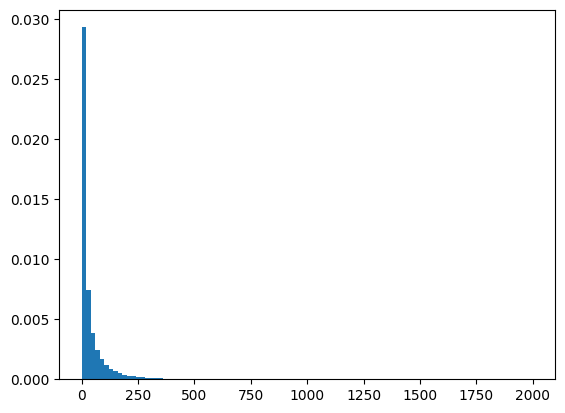

In [148]:
plt.hist(all_length[all_length < 2000], bins=100, density=True)
plt.show()

On average, books have between 1 and 130 words long chapters

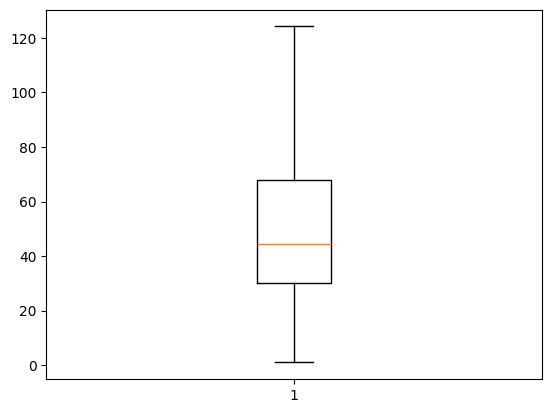

In [149]:
plt.boxplot(mean_length, showfliers=False)
plt.show()

The median length of the paragraphs are between 1 and 90 words long.

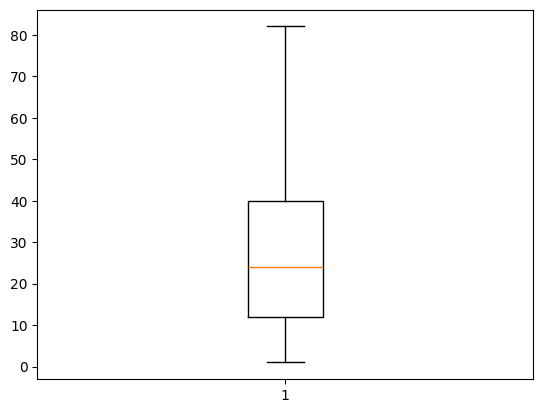

In [150]:
plt.boxplot(median_length, showfliers=False)
plt.show()

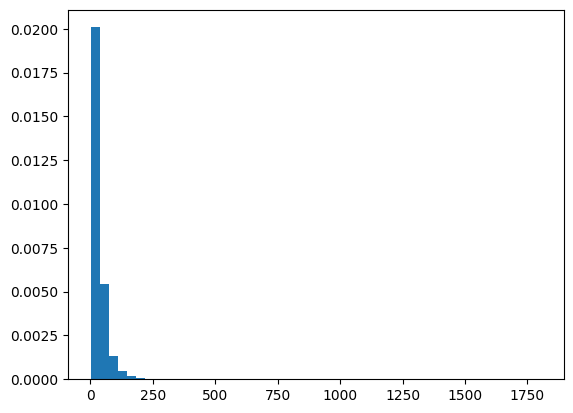

In [152]:
plt.hist(median_length, bins=50, density=True)
plt.show()

The maximum length of a pragraph in each novel is between 1 and 1500 words.

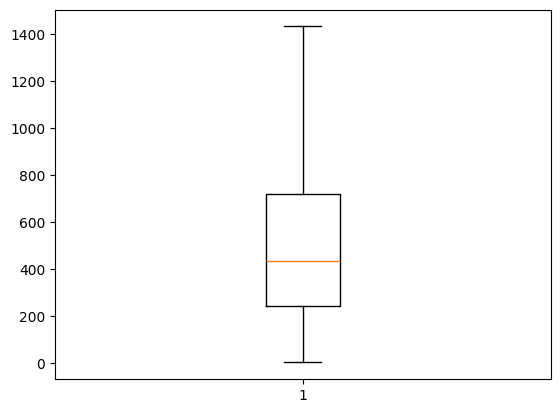

In [162]:
plt.boxplot(max_length, showfliers=False)
plt.show()

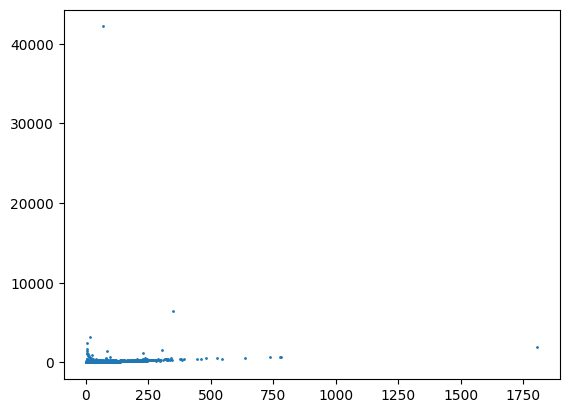

In [153]:
plt.scatter(median_length, mean_length, s=1)

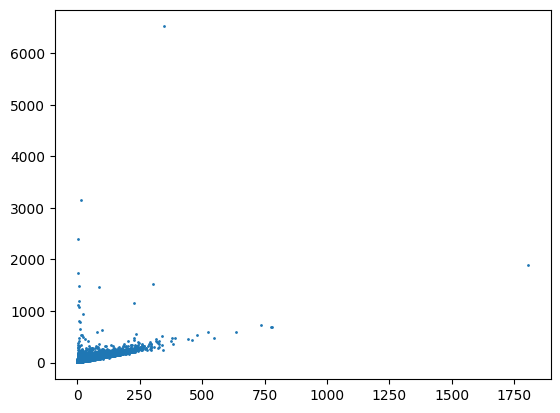

In [161]:
plt.scatter(median_length[mean_length < 10000], mean_length[mean_length < 10000], s=1)

In [160]:
np.corrcoef(median_length[mean_length < 10000], mean_length[mean_length < 10000])

array([[1.        , 0.60764085],
       [0.60764085, 1.        ]])

In [188]:
all_num_words[300][-10:]

[11, 12, 9, 9, 11, 6, 7, 1, 3, 9]

In [189]:
" ".join(kept_content[300].replace("\r\n", "\n").replace("\xa0", "").split("\n\n")).split("\n")[-10:]

['and all his greatness, he will shrink. Yet how proper and',
 'easy a step it would be! He could easily get better, but',
 'scarcely worse, associates. They appear to have one object',
 'in view, and only one—jobbery. It was chiefly owing',
 'to a most flagitious piece of jobbery, which one of his',
 'lordship’s principal colleagues sanctioned and promoted,',
 'that his lordship experienced his late parliamentary',
 'disasters.',
 '[8] A fact.',
 '***END OF THE PROJECT GUTENBERG EBOOK THE ROMANY RYE***']

In [ ]:
CHAPTER XLV

In [232]:
print(repr(kept_content[300][1000:2000]))

'rying narrowly\r\ninto the condition of the wheel and axletree—the latter had\r\nsustained no damage of any consequence, and the wheel, as far as\r\nI was able to judge, was sound, being only slightly injured in\r\nthe box.\xa0 The only thing requisite to set the chaise in a\r\ntravelling condition appeared to be a linch-pin, which I\r\ndetermined to make.\xa0 Going to the companion wheel, I took\r\nout the linch-pin, which I carried down with me to the dingle, to\r\nserve as a model.\r\nI found Belle by this time dressed, and seated near the forge:\r\nwith a slight nod to her like that which a person gives who\r\nhappens to see an acquaintance when his mind is occupied with\r\nimportant business, I forthwith set about my work.\xa0\r\nSelecting a piece of iron which I thought would serve my purpose,\r\nI placed it in the fire, and plying the bellows in a furious\r\nmanner, soon made it hot; then seizing it with the tongs, I laid\r\nit on my anvil, and began to beat it with my hammer, 

In [2]:
#print(kept_content[300])

In [3]:
#kept_content[300].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n\n", "||||||").split("||||||")

In [212]:
kept_content[300].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n\n", "\n\n").split("\n\n")[30]

'Footnotes\n[1] Tipperary.\n[2] An obscene oath.\n[3] See “Muses’\nLibrary,” pp. 86, 87. London, 1738.\n[4] Genteel with them seems to be\nsynonymous with Gentile and Gentoo; if so, the manner in which it\nhas been applied for ages ceases to surprise, for genteel is\nheathenish. Ideas of barbaric pearl and gold, glittering\narmour, plumes, tortures, blood-shedding, and lust, should always\nbe connected with it. Wace, in his grand Norman poem, calls\nthe Baron genteel:—\n“La furent li gentil Baron,” etc.'

In [4]:
#kept_content[300].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n\n", "\n\n").split("\n\n")[31]

In [5]:
#print(kept_content[300])

In [6]:
#print(kept_content[10])

In [120]:
all_processed = []
all_num_words = []
for l in tqdm(range(len(kept_content))):
    content = kept_content[l]
    print(content)
    paragraphs, n_words = chunk_in_paragraph(content)
    all_processed.append(paragraphs)
    all_num_words.append(n_words)

  2%|███▏                                                                                                                                                                          | 18/1000 [00:00<00:11, 86.54it/s]IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)

  5%|████████▎                                                                                                                                                                     | 48/1000 [00:00<00:13, 72.37it/s]IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopu

 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏        | 949/1000 [00:14<00:00, 91.52it/s]IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)

 97%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋     | 969/1000 [00:14<00:00, 65.54it/s]IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopu

In [518]:

all_processed = []
for content in tqdm(kept_content):
    all_processed.append(" ".join(content.replace("\r\n", "\n").replace("\xa0", "").split("\n\n")).split("\n"))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 39066/39066 [05:52<00:00, 110.82it/s]


In [521]:
(5*60+52)/len(all_processed)

0.009010392668816874

In [543]:
l1 = [1, 2]
l2 = []
l2.append(**l1)

TypeError: list.append() argument after ** must be a mapping, not list

In [541]:
l2

[1, 2]

In [533]:
import sys
sys.getsizeof(all_processed)*8/1e3

2808.512

In [522]:
processed_text =" ".join(kept_content[100].replace("\r\n", "\n").replace("\xa0", "").split("\n\n")).split("\n")

In [7]:
#" ".join(kept_content[100].replace("\r\n", "\n").replace("\xa0", "").split("\n\n")).split("\n")

In [523]:
processed_text_filtered = [(text, len(text.split(" "))) for text in processed_text if len(text) > 30]

In [8]:
#processed_text

In [509]:
len(processed_text)

1536

In [510]:
len(processed_text_filtered)

1360

In [9]:
#processed_text

In [512]:
paragraphs, sizes = list(zip(*processed_text_filtered))

(array([420., 183., 123., 103.,  94.,  93.,  64.,  46.,  49.,  28.,  29.,
         29.,  17.,  22.,  14.,   7.,   5.,   6.,   5.,   6.,   2.,   2.,
          1.,   0.,   3.,   2.,   1.,   0.,   0.,   2.,   0.,   2.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([   5. ,   29.8,   54.6,   79.4,  104.2,  129. ,  153.8,  178.6,
         203.4,  228.2,  253. ,  277.8,  302.6,  327.4,  352.2,  377. ,
         401.8,  426.6,  451.4,  476.2,  501. ,  525.8,  550.6,  575.4,
         600.2,  625. ,  649.8,  674.6,  699.4,  724.2,  749. ,  773.8,
         798.6,  823.4,  848.2,  873. ,  897.8,  922.6,  947.4,  972.2,
         997. , 1021.8, 1046.6, 1071.4, 1096.2, 1121. , 1145.8, 1170.6,
        1195.4, 1220.2, 1245. ]),
 <BarContainer object of 50 artists>)

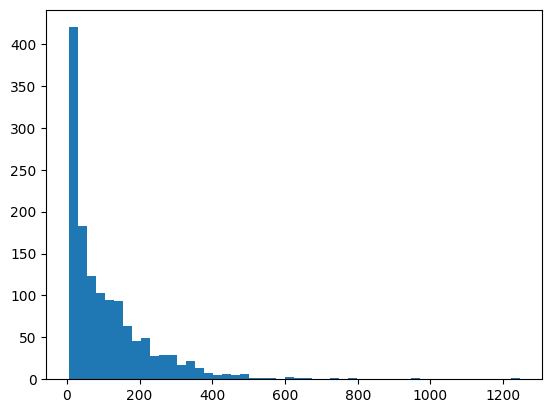

In [513]:
plt.hist(sizes, bins=50)

{'whiskers': [<matplotlib.lines.Line2D at 0x313934050>,
 'caps': [<matplotlib.lines.Line2D at 0x3139360f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x313935b20>],
 'medians': [<matplotlib.lines.Line2D at 0x313936630>],
 'fliers': [],
 'means': []}

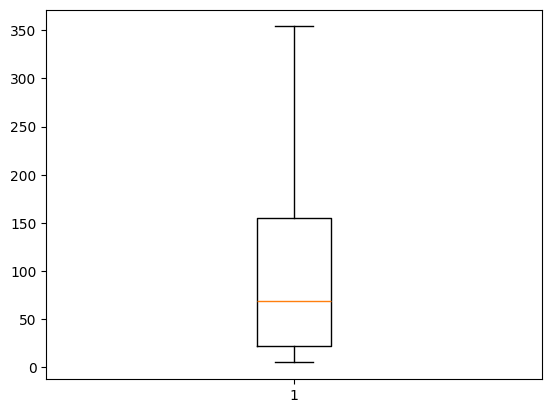

In [514]:
plt.boxplot(sizes, showfliers=False)

In [515]:
np.mean(sizes)

110.31764705882352

In [10]:
#test = " | ".join(processed_text)
#re.sub("\\| {0,35} \\|", "|", test)

In [473]:
len(" By Lewis Carroll ")

18

# Common pile dataset

Checking if the common pile dataset is more consistent in terms of spacing and paragraphs

In [12]:
common_pile_dataset = load_dataset("common-pile/project_gutenberg", split="train", streaming=False)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/52 [00:00<?, ?it/s]

In [13]:
common_pile_dataset["metadata"][0].keys()

dict_keys(['license', 'language', 'url', 'title'])

In [14]:
tuples_metadata_id = []
for t in tqdm(common_pile_dataset):
    row = t["metadata"]
    row.update({"id":t["id"]})
    tuples_metadata_id.append(row)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 71810/71810 [01:03<00:00, 1122.74it/s]


In [15]:
set([1, 2, 3]) == set([1, 2, 3])

True

In [16]:
metadata_id = pd.DataFrame.from_dict(tuples_metadata_id)
metadata_id.to_csv("../databases/metadata_ids.csv")

OSError: Cannot save file into a non-existent directory: '../databases'

In [17]:
metadata = metadata_id

In [259]:
metadata = pd.read_csv("../databases/metadata_ids.csv", index_col=0)
print(metadata.head())

         license language                                               url  \
0  Public Domain       en      https://www.gutenberg.org/ebooks/1.txt.utf-8   
1  Public Domain       en     https://www.gutenberg.org/ebooks/10.txt.utf-8   
2  Public Domain       en    https://www.gutenberg.org/ebooks/100.txt.utf-8   
3  Public Domain       it   https://www.gutenberg.org/ebooks/1000.txt.utf-8   
4  Public Domain       en  https://www.gutenberg.org/ebooks/10000.txt.utf-8   

                                               title     id  
0  The Declaration of Independence of the United ...      1  
1                The King James Version of the Bible     10  
2          The Complete Works of William Shakespeare    100  
3              La Divina Commedia di Dante: Complete   1000  
4                                    The Magna Carta  10000  


In [18]:
indices_df = pd.DataFrame([eval(l) for l in common_pile_dataset["id"]]).rename(columns={0:"text_id"})

In [23]:
catalog = pd.read_csv("https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv.gz", compression="gzip")
#metadata = pd.read_csv("../databases/metadata_ids.csv", index_col=0)
metadata = metadata.rename(columns={"id":"text_id"})
print(metadata.head())
metadata = pd.DataFrame.from_dict(common_pile_dataset["metadata"])[["url", "title"]]
indices_df = pd.DataFrame([eval(l) for l in common_pile_dataset["id"]]).rename(columns={0:"text_id"})
metadata = pd.concat([indices_df, metadata], axis=1)
merged_catalog_meta_data = pd.merge(catalog, metadata, how="inner", left_on="Text#", right_on="text_id")
merged_catalog_meta_data = merged_catalog_meta_data[["Language", "Title", "Authors", "Subjects", "text_id", "Bookshelves"]]

   text_id        license language  \
0        1  Public Domain       en   
1       10  Public Domain       en   
2      100  Public Domain       en   
3     1000  Public Domain       it   
4    10000  Public Domain       en   

                                                url  \
0      https://www.gutenberg.org/ebooks/1.txt.utf-8   
1     https://www.gutenberg.org/ebooks/10.txt.utf-8   
2    https://www.gutenberg.org/ebooks/100.txt.utf-8   
3   https://www.gutenberg.org/ebooks/1000.txt.utf-8   
4  https://www.gutenberg.org/ebooks/10000.txt.utf-8   

                                               title text_id  
0  The Declaration of Independence of the United ...       1  
1                The King James Version of the Bible      10  
2          The Complete Works of William Shakespeare     100  
3              La Divina Commedia di Dante: Complete    1000  
4                                    The Magna Carta   10000  


In [34]:
catalog[catalog["Text#"] == 71609]

,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
71430,71609,Text,2023-09-10,Andersonville diary,en,"Ransom, John L., 1843-1919","United States -- History -- Civil War, 1861-18...",E456,Category: Biographies; Category: History - Ame...


In [24]:
merged_catalog_meta_data.Language.value_counts(dropna=True)
print("Counts of languages", merged_catalog_meta_data.Language.value_counts(normalize=True))
merged_catalog_meta_data = merged_catalog_meta_data.loc[merged_catalog_meta_data.Language == "en"]
print("Count empty bookshelves", merged_catalog_meta_data.Bookshelves.isna().value_counts())
merged_catalog_meta_data = merged_catalog_meta_data[merged_catalog_meta_data.Bookshelves.isna() == False]

Counts of languages Language
en            0.800627
fr            0.051231
fi            0.040563
de            0.029701
nl            0.013916
                ...   
fi; sv        0.000014
en; la; el    0.000014
af; nl        0.000014
bo; en        0.000014
la; pt        0.000014
Name: proportion, Length: 110, dtype: float64
Count empty bookshelves Bookshelves
False    57321
True        96
Name: count, dtype: int64


In [25]:
def get_bookshelves(bookshelf):
    """
    Gets all the bookshelf for a book
    """
    splitted_result = re.split(r"[,;&]", bookshelf.replace("Category: ", "").lower().replace("-", "").replace(" ", ""))
    return splitted_result if type(splitted_result) == list else [splitted_result]

In [26]:
merged_catalog_meta_data.Bookshelves_bag_of_words = merged_catalog_meta_data.Bookshelves.apply(get_bookshelves)
bag_of_words = merged_catalog_meta_data.Bookshelves_bag_of_words.sum()

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_96059/3062993558.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  merged_catalog_meta_data.Bookshelves_bag_of_words = merged_catalog_meta_data.Bookshelves.apply(get_bookshelves)


In [27]:
np.unique(bag_of_words)

array(['18951923', '6bestlovedspanishliteraryclassics', 'adventure',
       'africa', 'africanamericanwriters', "ainslee's",
       'amagazineofverse', 'american', 'americanliterature',
       'americanrevolutionarywar', 'amusement', 'anarchism',
       'anddramaticcensor', 'andinstruction', 'andmathematics',
       'andscience', 'animal', 'animalsdomestic', 'animalswild',
       'animalswildbirds', 'animalswildinsects', 'animalswildmammals',
       'animalswildreptilesandamphibians', 'animalswildtrapping',
       'anthropology', 'archaeology', 'architecture', 'argentina',
       "armour'smonthlycookbook", 'art', 'arthurianlegends',
       'astoundingstories', 'astronomy', 'atheism', 'australia',
       "bannedbooksfromannehaight'slist",
       'bannedbookslistfromtheamericanlibraryassociation',
       'bestbookseverlistings', 'bestsellers', 'bibliomania',
       'biographies', 'biology', 'birdlore', 'birds',
       "blackwood'sedinburghmagazine", 'boerwar', 'botany', 'britishlaw',
   

In [28]:
genre_to_keep = set(['novels',
         'britishliterature',
         'adventure',
         'americanliterature',
         'children',
         'youngadultreading',
         'sciencefiction',
         'biographies',
         'historyamerican',
         'historymodern(1750+)', 
         'fantasy',
         'shortstories',
         'historicalnovels',
         'historybritish',
         'travelwriting',
         'historywarfare',
         'historyother',
         'folklore',
         'mythology',
         'legends', 
         'historyeuropean', 
         'romance',
         'crime',
         'thrillersandmystery',
         'historyearlymodern(c.14501750)',
         'frenchliterature',
         'classicsofliterature'])



freqs = Counter(bag_of_words)
genre_to_skip = ['anddramaticcensor', 'andinstruction', 'andmathematics',
       'andscience', 'animal', 'animalsdomestic', 'animalswild',
       'animalswildbirds', 'animalswildinsects', 'animalswildmammals',
       'animalswildreptilesandamphibians', 'animalswildtrapping',
       'anthropology', 'archaeology', 'architecture', 'astronomy', 'biology', 'birdlore', 'birds', 'botany', 'britishlaw', 
        'buddhism', 'bulgaria', 'business/management', 'camping', 'canada',
       'canonlaw', 'celticmagazine', "chambers'sedinburghjournal",
       'chemistry', "child'sownbookofgreatmusicians", 'children',
       "children'santhologies", "children'sbiography",]

In [29]:
def keep_on_genre(l, to_keep):
    """
    Check if the book is at least in one of the genre we want to keep
    """
    return set(l).intersection(to_keep) != set()

def keep_on_genre_exclusive(l, to_keep):
    """
    Check if the book is at least in one of the genre we want to keep
    """
    return set(l).issubset(to_keep)

mask_genres_non_excluive = merged_catalog_meta_data.Bookshelves_bag_of_words.apply(keep_on_genre, args=(genre_to_keep, ))
kept_books_non_exclusive = merged_catalog_meta_data[mask_genres_non_excluive]

mask_genres = merged_catalog_meta_data.Bookshelves_bag_of_words.apply(keep_on_genre_exclusive, args=(genre_to_keep, ))
kept_books = merged_catalog_meta_data[mask_genres]

In [30]:
print("Percentage of kept work non exclusive:", kept_books_non_exclusive.shape[0]/merged_catalog_meta_data.shape[0])
print("Number of ducplicated rows non exclusive", kept_books_non_exclusive.text_id.duplicated().sum())

print("Percentage of kept work:", kept_books.shape[0]/merged_catalog_meta_data.shape[0])
print("Number of ducplicated rows", kept_books.text_id.duplicated().sum())

Percentage of kept work non exclusive: 0.8090926536522391
Number of ducplicated rows non exclusive 0
Percentage of kept work: 0.4132865790896879
Number of ducplicated rows 0


In [31]:
mask_content = metadata.text_id.apply(lambda x: x in kept_books.text_id.values)
mask_content.mean()
kept_indices = np.where(mask_content == True)

In [32]:
common_pile_dataset_filtered = common_pile_dataset.filter(lambda x: eval(x["id"]) in kept_books.text_id.values)

Filter:   0%|          | 0/71810 [00:00<?, ? examples/s]

In [38]:
all_titles = pd.DataFrame.from_dict({"title":common_pile_dataset_filtered["metadata"]["title"]})

In [40]:
"AA".lower()

'aa'

In [43]:
all_titles

,title
0,A Voyage to the Moon\r\nWith Some Account of t...
1,La Fiammetta
2,The Mystery
3,Beneath the Banner: Being Narratives of Noble ...
4,Gaslight Sonatas
...,...
23685,The Spenders: A Tale of the Third Generation
23686,Philothea: A Grecian Romance
23687,Wylder's Hand
23688,Stories by Foreign Authors: Spanish


In [53]:
all_titles_processed = all_titles["title"].apply(lambda t: t.lower().replace(" ", "").replace(":", "").replace("-", "").replace("\r\n", ""))

In [57]:
all_titles_processed.duplicated().sum()

np.int64(243)

In [33]:
def chunk_in_paragraph(content, n_words, threshold=30):
    """
    Chunks a book into paragraphs.
    arguments:
    content -- content of the book as a str.
    n_words -- list of lists, containing the number of words for each paragraph.
    keyword arguments:
    threshold -- number of words under which we discard the paragraph.
    """
    paragraphs = content.replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
    filtered_paragraphs = []
    n_words = []
    for p in paragraphs:
        if len(p) > threshold:
            filtered_paragraphs.append(p)
            n_words.append(len(p.split(" ")))
            
    return paragraphs, n_words


def compute_num_words(content):
    """
    Chunks a book into paragraphs
    arguments:
    content -- content of the book as a str
    """
    paragraphs = content.replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
    n_words = [len(text.split(" ")) for text in paragraphs]
    return n_words

def len_chapter_paragraph(content):
    """Counts the number of words in a paragraph with a chapter word"""
    paragraphs = content.replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
    n_words = [len(text.split(" ")) for text in paragraphs if "chapter" in text.lower()]
    return n_words

def count_empty_chapters(content):
    paragraphs = content.replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
    n_words_empty = [1 for text in paragraphs if text == ""]
    return sum(n_words_empty)

In [335]:
all_num_words = []
for l in tqdm(range(len(common_pile_dataset))):
    content = common_pile_dataset["text"][l]
    n_words = compute_num_words(content)
    all_num_words.append(n_words)
    
all_length = np.array([l for t in all_num_words for l in t])
mean_length = np.array([np.mean(t) for t in all_num_words])
median_length = np.array([np.median(t) for t in all_num_words])
max_length = np.array([np.max(t) for t in all_num_words])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23690/23690 [06:19<00:00, 62.34it/s]


In [406]:
np.mean(all_length < 3)

0.0497551360420357

In [452]:
np.mean(all_length < 5)

0.09912569053399936

In [466]:
shorted_than_indexes = np.where(np.array(all_num_words[23005]) < 10)[0]

CHAPTER, LETTER, Illustration

said, cried, replied, whispered, interrupted

So the rule might be: less than 10 words, with quotes, we can remove
Anything that is purely CAPITAL, we remove. Anything less than 3 words, we remove.

In [518]:
indx = 35
shorted_than_indexes = np.where(np.array(all_num_words[indx]) < 10)[0]
t = common_pile_dataset["text"][indx].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
np.array(t)[shorted_than_indexes][16]

'"What!" she screamed.'

In [519]:
"""\"""" in np.array(t)[shorted_than_indexes][16]

True

In [472]:
print(common_pile_dataset["text"][indx])

This eBook was produced by Dagny,
                and David Widger,





BOOK IV.

  "Strange is the land that holds thee,--and thy couch
   is widow'd of the loved one."
     EURIP. /Med./ 442
       Translation by R. G.



CHAPTER I.

               "I, alas!
   Have lived but on this earth a few sad years;
   And so my lot was ordered, that a father
   First turned the moments of awakening life
   To drops, each poisoning youth's sweet hope."
     "/Cenci/."

FROM accompanying Maltravers along the noiseless progress of mental
education, we are now called awhile to cast our glances back at the
ruder and harsher ordeal which Alice Darvil was ordained to pass.  Along
her path poetry shed no flowers, nor were her lonely steps towards the
distant shrine at which her pilgrimage found its rest lighted by the
mystic lamp of science, or guided by the thousand stars which are never
dim in the heavens for those favoured eyes from which genius and fancy
have removed many of the films of clay.  

In [361]:
all_num_words_chapter = []
for l in tqdm(range(len(common_pile_dataset))):
    content = common_pile_dataset["text"][l]
    n_words = len_chapter_paragraph(content)
    all_num_words_chapter.append(n_words)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23690/23690 [05:24<00:00, 73.11it/s]


In [391]:
all_num_empty_chapters = []
for l in tqdm(range(len(common_pile_dataset))):
    content = common_pile_dataset["text"][l]
    n_words = count_empty_chapters(content)
    all_num_empty_chapters.append(n_words)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23690/23690 [04:43<00:00, 83.42it/s]


Many chapters are actually empty: 2 percent of the total chapters.

In [394]:
sum(all_num_empty_chapters)/len(all_length)

0.02243926952353158

In [363]:
all_length_chapter = np.array([l for t in all_num_words_chapter for l in t])
mean_length_chapter = np.array([np.mean(t) for t in all_num_words_chapter])
median_length_chapter = np.array([np.median(t) for t in all_num_words_chapter])
#max_length_chapter = np.array([np.max(t) for t in all_num_words_chapter])

One percent of the paragraphs contain the word chapter

In [367]:
len(all_length_chapter)/len(all_length)

0.013892671116585487

In [398]:
len(all_length_chapter[all_length_chapter < 20])/len(all_length)

0.010157955557700838

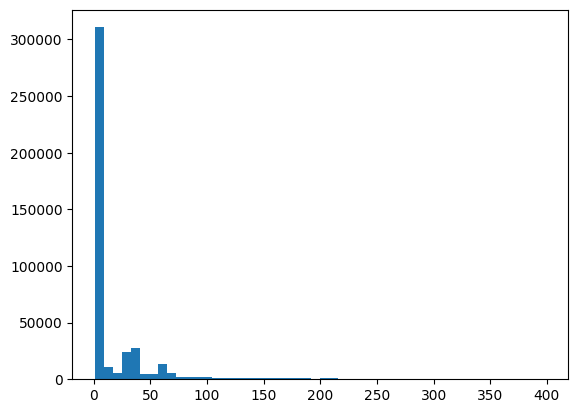

In [372]:
plt.hist(all_length_chapter[all_length_chapter < 400], bins=50)
plt.show()

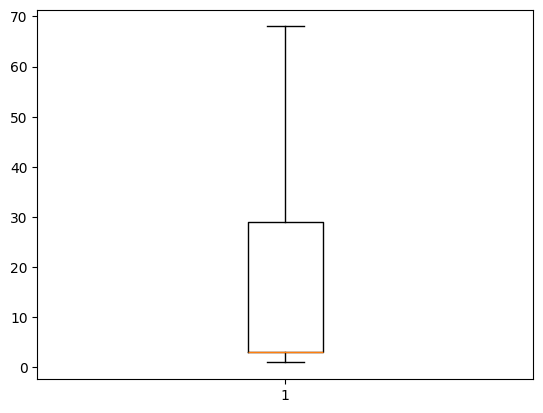

In [373]:
plt.boxplot(all_length_chapter, showfliers=False)
plt.show()

In [382]:
all_num_words_chapter[0][22]

443

In [383]:
print(common_pile_dataset["text"][0])

Produced by Christine De Ryck, Stig M. Valstad, Suzanne L. Shell
and PG Distributed Proofreaders




                      A
             VOYAGE TO THE MOON:
                     WITH
                 SOME ACCOUNT
                    OF THE
  MANNERS AND CUSTOMS, SCIENCE AND PHILOSOPHY,
                    OF THE
              PEOPLE OF MOROSOFIA,
                     AND
                OTHER LUNARIANS.



        BY GEORGE TUCKER (JOSEPH ATTERLEY)




    "It is the very error of the moon,
    She comes more near the earth than she was wont,
    And makes men mad."--_Othello_.



                    1827


     CONTENTS.



     CHAPTER I.

Atterley's birth and education--He makes a voyage--
  Founders off the Burman coast--Adventures in
  that Empire--Meets with a learned Brahmin from
  Benares.

     CHAPTER II.

The Brahmin's illness--He reveals an important secret
  to Atterley--Curious information concerning the
  Moon--The Glonglims--They plan a voyage to
  the Moon.

     CHAP

In [387]:
t = common_pile_dataset["text"][0].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
[x for x in t if "chapter" in x.lower()]

['     CHAPTER I.',
 '     CHAPTER II.',
 '     CHAPTER III.',
 '     CHAPTER IV.',
 '     CHAPTER V.',
 '     CHAPTER VI.',
 '     CHAPTER VII.',
 '     CHAPTER VIII.',
 '     CHAPTER IX.',
 '     CHAPTER X.',
 '     CHAPTER XI.',
 '     CHAPTER XII.',
 '     CHAPTER XIII.',
 '     CHAPTER XIV.',
 '     CHAPTER XV.',
 '     CHAPTER XVI.',
 '     CHAPTER XVII.',
 ' CHAPTER I.',
 ' CHAPTER II.',
 ' CHAPTER III.',
 ' CHAPTER IV.',
 ' CHAPTER V.',
 "Left now to my own meditations, and unsupported by the example and conversation of my friend, I felt my first apprehensions return, and began seriously to regret my rashness in thus venturing on so bold an experiment, which, however often repeated with success, must ever be hazardous, and which could plead little more in its favour than a vain and childish curiosity. I took up a book, but whilst my eye ran over the page, I understood but little what I read, and could not relish even that. I now looked down through the telescope, and found the 

In [366]:
len(all_length)

31863203

In [148]:
common_pile_dataset["text"][1605].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")

['Produced by David Widger',
 '',
 '',
 ' NIGHT WATCHES',
 'by W.W. Jacobs',
 '',
 ' STEPPING BACKWARDS',
 '"Wonderful improvement," said Mr. Jack Mills.  "Show \'em to me again."',
 'Mr. Simpson took his pipe from his mouth and, parting his lips, revealed his new teeth.',
 '"And you talk better," said Mr. Mills, taking his glass from the counter and emptying it; "you ain\'t got that silly lisp you used to have.  What does your missis think of \'em?"',
 '"She hasn\'t seen \'em yet," said the other.  "I had \'em put in at dinner- time.  I ate my dinner with \'em."',
 'Mr. Mills expressed his admiration.  "If it wasn\'t for your white hair and whiskers you\'d look thirty again," he said, slowly.  "How old are you?"',
 '"Fifty-three," said his friend.  "If it wasn\'t for being laughed at I\'ve often thought of having my whiskers shaved off and my hair dyed black. People think I\'m sixty."',
 '"Or seventy," continued Mr. Mills.  "What does it matter, people laughing?  You\'ve got a splendi

In [143]:
print(common_pile_dataset["text"][1605])

Produced by David Widger






NIGHT WATCHES

by W.W. Jacobs




STEPPING BACKWARDS

"Wonderful improvement," said Mr. Jack Mills.  "Show 'em to me again."

Mr. Simpson took his pipe from his mouth and, parting his lips, revealed
his new teeth.

"And you talk better," said Mr. Mills, taking his glass from the counter
and emptying it; "you ain't got that silly lisp you used to have.  What
does your missis think of 'em?"

"She hasn't seen 'em yet," said the other.  "I had 'em put in at dinner-
time.  I ate my dinner with 'em."

Mr. Mills expressed his admiration.  "If it wasn't for your white hair
and whiskers you'd look thirty again," he said, slowly.  "How old are
you?"

"Fifty-three," said his friend.  "If it wasn't for being laughed at I've
often thought of having my whiskers shaved off and my hair dyed black.
People think I'm sixty."

"Or seventy," continued Mr. Mills.  "What does it matter, people
laughing?  You've got a splendid head of 'air, and it would dye
beautiful."

Mr. Simp

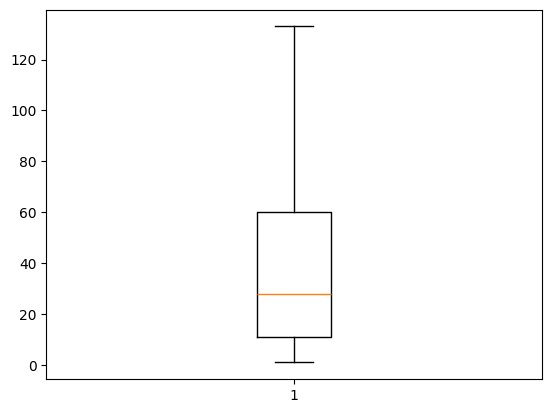

In [336]:
plt.boxplot(all_length, showfliers=False)
plt.show()

In [338]:
np.percentile(all_length, 99)

333.0

In [339]:
np.percentile(all_length, 1)

1.0

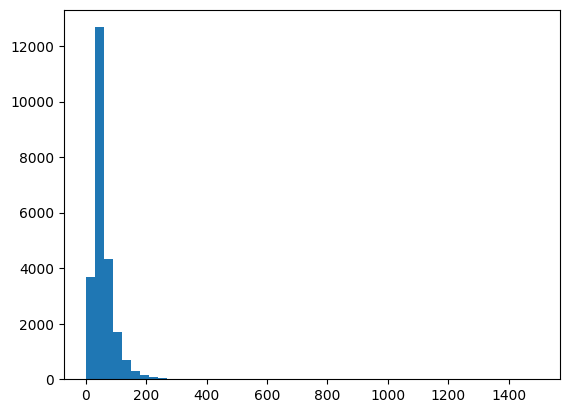

In [340]:
plt.hist(mean_length, bins=50)
plt.show()

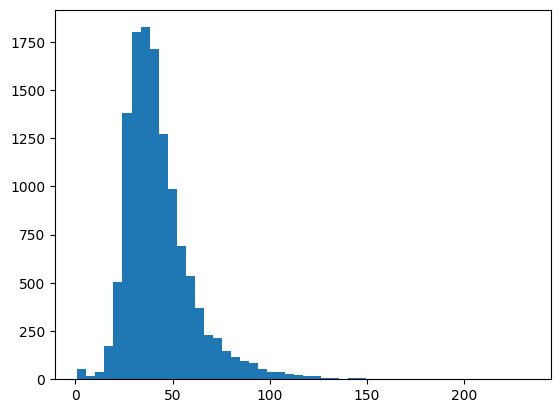

In [341]:
plt.hist(mean_length[max_length <500], bins=50)
plt.show()

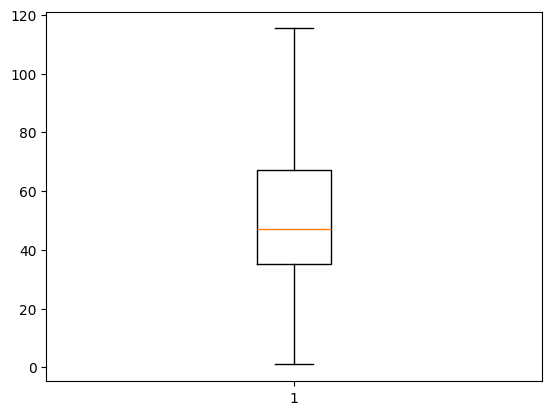

In [342]:
plt.boxplot(mean_length, showfliers=False)
plt.show()

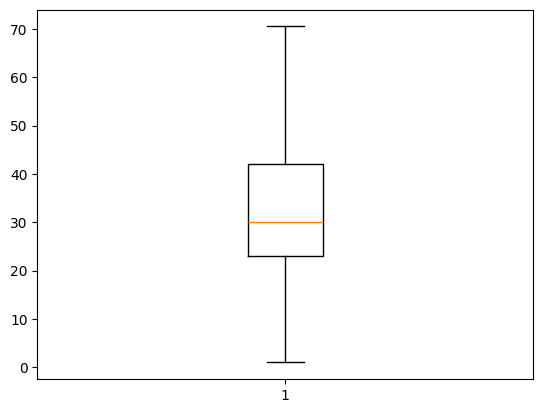

In [343]:
plt.boxplot(median_length, showfliers=False)
plt.show()

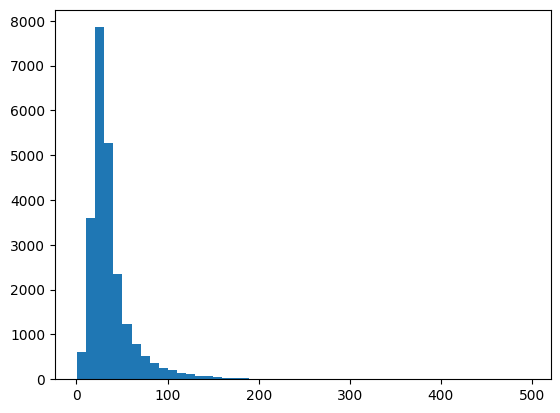

In [344]:
plt.hist(median_length, bins=50)
plt.show()

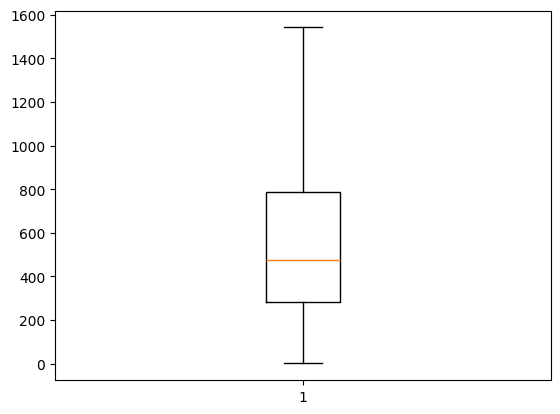

In [345]:
plt.boxplot(max_length, showfliers=False)
plt.show()

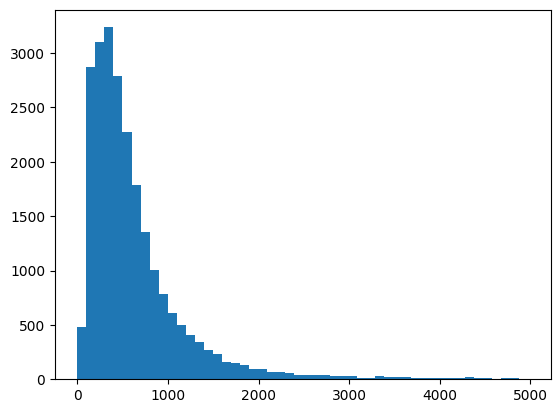

In [346]:
plt.hist(max_length[max_length<5000], bins=50)
plt.show()

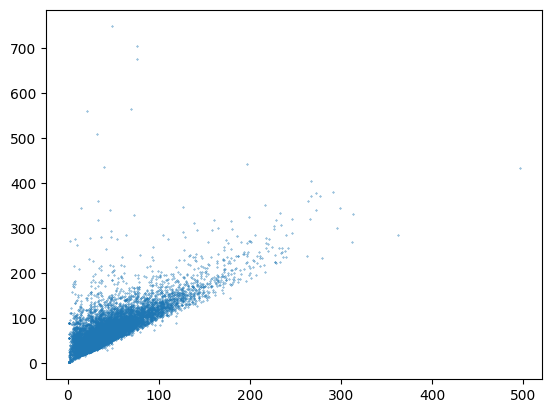

In [347]:
plt.scatter(median_length[mean_length <1000], mean_length[mean_length<1000], s=0.1)
plt.show()

In [348]:
np.corrcoef(median_length[mean_length <1000], mean_length[mean_length<1000])

array([[1.        , 0.81408032],
       [0.81408032, 1.        ]])

Conclusion: 99 % of the paragraph are under 379 words, and 99 % of the paragraph are above 1 word.

In [356]:
np.where(np.array(all_num_words[23000]) < 10)

(array([   0,    1,    2,    3,    4,    5,    6,   13,   20,   27,   41,
          48,   49,   76,   91,   92,   98,  134,  145,  146,  153,  171,
         180,  185,  186,  192,  195,  197,  198,  211,  212,  228,  229,
         245,  263,  264,  267,  268,  270,  272,  275,  276,  279,  282,
         285,  286,  287,  297,  299,  300,  309,  316,  317,  320,  321,
         327,  340,  351,  353,  356,  360,  361,  364,  365,  366,  367,
         378,  379,  413,  414,  429,  431,  434,  436,  439,  442,  443,
         462,  463,  486,  487,  514,  516,  517,  521,  522,  530,  531,
         544,  545,  556,  557,  572,  588,  595,  609,  610,  612,  613,
         624,  625,  636,  659,  675,  676,  691,  692,  693,  701,  703,
         704,  712,  713,  736,  737,  744,  756,  757,  762,  763,  764,
         765,  767,  768,  771,  776,  783,  784,  799,  803,  809,  810,
         812,  813,  815,  816,  817,  826,  827,  837,  838,  839,  843,
         844,  866,  867,  872,  882, 

In [359]:
t = common_pile_dataset[23000]["text"].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
t[1685]

'Adieu, ever, my dear Duke. Most truly yours, etc.'

In [215]:
print(common_pile_dataset[30000]["text"])

Produced by David Widger from page images generously provided by the
Internet Archive




IN THE LEVANT.

By Charles Dudley Warner,

Twenty Fifth Impression

Boston: Houghton, Mifflin And Company

1876


TO WILLIAM D. HOWELLS THESE NOTES OF ORIENTAL TRAVEL ARE FRATERNALLY
INSCRIBED.





CONTENTS

PREFACE

IN THE LEVANT.

I.—FROM JAFFA TO JERUSALEM.

II.—JERUSALEM.

III.—HOLY PLACES OP THE HOLY CITY.

IV.—NEIGHBORHOODS OF JERUSALEM.

V.—GOING DOWN TO JERICHO.

VI.—BETHLEHEM AND MAR SABA.

VII.—THE FAIR OF MOSES; THE ARMENIAN PATRIARCH.

VIII.—DEPARTURE FROM JERUSALEM.

IX.—ALONG THE SYRIAN COAST.

X.—BEYROUT.—OVER THE LEBANON.

XI.—BA'ALBEK.

XII.—ON THE ROAD TO DAMASCUS.

XIII.—THE OLDEST OF CITIES.

XIV.—OTHER SIGHTS IN DAMASCUS.

XV.—SOME PRIVATE HOUSES.

XVI.—SOME SPECIMEN TRAVELLERS.

XVII.—INTO DAYLIGHT AGAIN.—AN EPISODE OF TURKISH JUSTICE.

XVIII.—CYPRUS.

XIX.—THROUGH SUMMER SEAS.—RHODES.

XX.—AMONG THE ÆGEAN ISLANDS.

XXI.—SMYRNA AND EPHESUS.

XII.—THE ADVENTURERS.

XXIII.—THR

In [450]:
np.mean(np.array(all_length) < 5)

0.09912569053399936

In [233]:
np.mean(np.array(all_length) < 10)

0.24229499016972258

In [247]:
np.where((np.array(all_num_words[24567]) <10) & (np.array(all_num_words[24567])>5))

(array([   8,   28,   41,   44,   58,   76,   80,   81,   84,   97,  103,
         106,  107,  108,  118,  119,  121,  123,  161,  164,  167,  185,
         192,  195,  197,  199,  200,  220,  225,  229,  258,  259,  295,
         296,  299,  314,  323,  326,  328,  333,  334,  352,  356,  376,
         378,  385,  387,  391,  400,  413,  414,  421,  427,  431,  432,
         433,  439,  444,  450,  451,  458,  459,  476,  483,  498,  505,
         507,  519,  539,  540,  543,  544,  545,  546,  563,  564,  572,
         582,  590,  604,  609,  615,  621,  626,  647,  653,  667,  669,
         681,  684,  689,  706,  723,  725,  728,  734,  740,  741,  744,
         745,  762,  768,  771,  785,  794,  797,  806,  807,  815,  842,
         870,  872,  894,  896,  904,  919,  929,  934,  957,  966,  973,
         974,  989, 1028, 1033, 1053, 1056, 1059, 1064, 1067, 1078, 1080,
        1084, 1094, 1097, 1104, 1115, 1116, 1121, 1129, 1130, 1136, 1150,
        1158, 1165, 1176, 1179, 1182, 

In [253]:
t = common_pile_dataset[24567]["text"].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
t[391]

'“By Jove! I believe you’re right,” said Jack.'

In [231]:
len(all_length)/1e6

59.232306

In [281]:
np.where(np.array(all_num_words[3049]) >1000)

(array([17]),)

In [282]:
t = common_pile_dataset[3049]["text"].replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
t[17]

"   +----------------------------------------------------------------------+   |                                                                      |   |                    JOHANNA SPYRI'S ALPINE STORIES                    |   |                                                                      |   |                                                                      |   |  GRITLI'S CHILDREN. Complete Edition. Translated by LOUISE BROOKS.   |   |                      Illustrated in color. 8vo.                      |   |                                                                      |   | HEIDI. Complete Edition. Translated by HELENE S. WHITE. 16 full-page |   |                     illustrations in color. 8vo.                     |   |                                                                      |   | LITTLE ALPINE MUSICIAN. Translated by HELEN B. DOLE. Illustrated in  |   |                             color. 8vo.                              |   |                    

In [275]:
print(common_pile_dataset[250]["text"])

Produced by Jon Ingram, David King, and the Online Distributed
Proofreading Team





The Crisis of the
Naval War


By
ADMIRAL OF THE FLEET
VISCOUNT JELLICOE OF SCAPA
G.C.B., O.M., G.C.V.O.


_With 8 Plates and 6 Charts_


1920




CONTENTS


CHAPTER

1. ADMIRALTY ORGANIZATION: THE CHANGES IN 1917

2. SUBMARINE CAMPAIGN IN THE EARLY PART OF 1917

3. ANTI-SUBMARINE OPERATIONS

4. THE INTRODUCTION OF THE CONVOY SYSTEM

5. THE CONVOY SYSTEM AT WORK

6. THE ENTRY OF THE UNITED STATES: OUR NAVAL POLICY EXPLAINED

7. PATROL CRAFT AND MINESWEEPING SERVICES

8. THE DOVER PATROL AND THE HARWICH FORCES

9. THE SEQUEL

10. "PRODUCTION" AT THE ADMIRALTY DURING 1917

11. NAVAL WORK

12. THE FUTURE

INDEX




LIST OF PLATES


A Mine Exploding

A German Submarine of the U-C Type

A German Submarine of the later Cruiser Class

A Smoke Screen for a Convoy

The Dummy Deck-house of a Decoy Ship

A Convoy Zigzagging

A Convoy with an Airship

Drifters at Sea

A Paddle Minesweeper

A German Mine on the Sur

In [267]:
common_pile_dataset[245]["id"]

'1040'

In [271]:
catalog[catalog["Text#"] == 1040]

,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
1021,1040,Text,1997-09-01,The Three Taverns: A Book of Poems,en,"Robinson, Edwin Arlington, 1869-1935",American poetry; Lyric poetry,PS,Category: Poetry; Category: American Literature


In [269]:
metadata[metadata.text_id == 1040]

,text_id,url,title
319,1040,https://www.gutenberg.org/ebooks/1040.txt.utf-8,The Three Taverns: A Book of Poems


In [407]:
def compute_number_of_dialogue(content, threshold=5):
    """Computes, among the paragraph of less than threshold words, the ones that are dialogue"""
    paragraphs = content.replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'").split("||||")
    l = []
    for p in paragraphs:
        if len(p.split(" ")) < 10:
            l.append("""“""" in content)
        else:
            l.append("ABOVE")
        
    return l

In [408]:
results = []
for book in tqdm(common_pile_dataset["text"]):
    results.append(compute_number_of_dialogue(book))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23690/23690 [03:19<00:00, 118.45it/s]


In [409]:
flattened_results = [a for r in results for a in r]

In [419]:
np.mean(np.array(flattened_results) == False)

0.0

In [307]:
len(flattened_results)/len(all_length)

0.11428680490676828

In [309]:
len(all_length)/1e6

59.232306

In [289]:
"""“""" in '“By Jove! I believe you’re right,” said Jack.'

True

In [293]:
common_pile_dataset

Dataset({
    features: ['id', 'text', 'source', 'added', 'metadata'],
    num_rows: 46378
})

In [350]:
len(common_pile_dataset)

23690

In [420]:
import sys
sys.getsizeof(common_pile_dataset)

48

In [436]:
common_pile_dataset.dataset_size/1e9

26.246637218

In [440]:
len(common_pile_dataset["id", "text"])

ValueError: invalid literal for int() with base 10: 'text'

In [449]:
common_pile_dataset.select_columns(["id", "text"]).dataset_size/(1024 ** 3)

24.4440857488662

In [647]:
"CHAPTER VIII.".lower()

'chapter viii.'

In [707]:
re.search(r"(^(?i:CHAPTER) )?[IVXLCDM]+", " I ")

<re.Match object; span=(1, 2), match='I'>

In [811]:
re.search(r"a +--b", "ojjla --b")

<re.Match object; span=(4, 9), match='a --b'>

In [868]:
re.search(r"^Chapter [A-Z][a-zA-Z]{2,13}", "Chapter One")

<re.Match object; span=(0, 11), match='Chapter One'>

In [312]:
test = "[footnote: this is a footnote"
l_test = test.split()
compute_inclusion_condition(l_test, test)

False

In [291]:
pattern_chapter = re.compile(r"^(?i:CHAPTER) [IVXLCDM]+|^[IVXLCDM]+$|^[A-Z ]{2,}\.{0,1}$|^No. [0-9]+--[A-Z ]+|^Part [IVXLCDM]+.{0,1}$|^Chapter [A-Z][a-zA-Z]{2,13}|^\s*(\*\s*){3,}\*\s*$")

def compute_inclusion_condition(words, p):
    """
    Computes whether to include the pararaph or not
    arguments:
    words -- list words in the paragraph
    p -- full paragraph
    """
    p = p.strip()
    more_three_words = len(words) > 3
    not_dialog = len(words) > 10 or ("""\"""" not in p and """“""" not in p and """\'""" not in p)
    not_all_upper = not p.isupper()
    is_not_footnote = re.search(r"\[footnote.+", p.lower()) is None
    is_not_transcribers = re.search(r"\[transcriber.+", p.lower()) is None
    is_not_illustration = re.search(r"\[illustration", p.lower()) is None
    return more_three_words and not_dialog and not_all_upper and is_not_footnote and is_not_illustration
    
def pipeline(book, text_id):
    """
    This function chunks a book into paragraphs, keeps track of the chapterization, span in the origina text 
    and the text id.
    parameters:
    book -- str, content of the book, unprocessed.
    text_id -- integer, id of the text.
    return:
    list of dict, paragraphs in the book.
    """
    start_t = time()
    start = time()
    paragraphs = book.replace("\r\n", "\n").replace("\xa0", "").replace("\n\n", "||||").replace("\n", " ").replace("\'","'")
    end = time()
    all_paragraphs = []
    all_text_id = []
    all_span = []
    all_chapter = []
    no_chapterization = False
    if re.search(pattern_chapter, paragraphs) is None:
        no_chapterization = True
        
    paragraphs_chunks = paragraphs.split("||||")
    l_processed_paragrahs = []
    chapter = None
    for l, p in enumerate(paragraphs_chunks):
        match = re.search(pattern_chapter, p.strip())
        if match is not None:
            chapter = match.group()
            continue
            
        if chapter is not None or no_chapterization:
            words = p.split()
            start_cond = time()
            condition_inclusion = compute_inclusion_condition(words, p)
            end_cond = time()
            if condition_inclusion:
                result_search = re.search(re.escape(p), paragraphs)
                assert result_search is not None, f"Cannot find paragraph number {l} in original text id {text_id}: {p}"
                all_paragraphs.append(p)
                all_text_id.append(text_id)
                all_span.append(result_search.span())
                all_chapter.append(chapter)
                #l_processed_paragrahs.append({"paragraph":p, "text_id":text_id, "span":result_search.span(), "chapter":chapter})
       
    if all_text_id == []:
        l_processed_paragrahs.append({"paragraph":[], "text_id":text_id, "span":None})
        
        all_paragraphs = []
        all_text_id = []
        all_span = []
        all_chapter = []
    
    return all_paragraphs, all_text_id, all_span, all_chapter

def map_pipeline(sample_batch):
    """
    Wrapper function apply pipeline to the rows of the Hugging Face dataset.
    """
    batch = {"paragraphs":[], "text_id":[], "span":[], "chapter":[]}
    for l in range(len(sample_batch["id"])):
        all_paragraphs, all_text_id, all_span, all_chapter = pipeline(sample_batch["text"][l], int(sample_batch["id"][l]))
        batch["paragraphs"] += all_paragraphs
        batch["text_id"] += all_text_id
        batch["span"] += all_span
        batch["chapter"] += all_chapter
        
    return batch

In [292]:
common_pile_dataset

Dataset({
    features: ['id', 'text', 'source', 'added', 'metadata'],
    num_rows: 71810
})

In [295]:
test_texts = common_pile_dataset_filtered.map(map_pipeline, batched=True, num_proc= 8, batch_size=128, remove_columns=["id", "text", "source", "added", "metadata"])

Map (num_proc=8):   0%|          | 0/23690 [00:00<?, ? examples/s]

In [298]:
len(test_texts)/1e6

24.953833

In [278]:
test_texts["paragraphs"]

Column([[], [], [], [], [], ...])

In [255]:
n_rows = 0 
for e in tqdm(test_texts):
    n_rows += 1

1200it [13:32,  1.48it/s]


KeyboardInterrupt: 

In [202]:
#test_texts = common_pile_dataset["text"]
test_idx = common_pile_dataset["id"]
all_processed = []
for data in test_texts:
    print(data)
    all_processed.append(pipeline(data, test_idx[i]))
    

In [203]:
all_processed

[]

In [189]:
all_processed

[([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], [], []),
 ([], [], []

In [1156]:
len(common_pile_dataset["text"])

23690

In [1158]:
np.where(np.array(all_len_processed) == 4)

(array([   630,    782,    810, ..., 343378, 343588, 343773]),)

In [1159]:
all_len_processed = [len(t["paragraph"].split(" ")) for text in all_processed for t in text]
len_processed = [[len(t["paragraph"].split(" ")) for t in text] for text in all_processed]
avg_per_book = [np.mean(len_paragraph) for len_paragraph in len_processed]
median_per_book = [np.median(len_paragraph) for len_paragraph in len_processed]

In [1160]:
len(all_len_processed)

341006

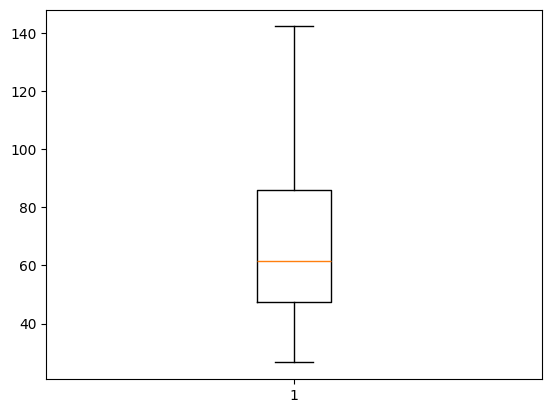

In [1161]:
plt.boxplot(avg_per_book, showfliers=False)
plt.show()

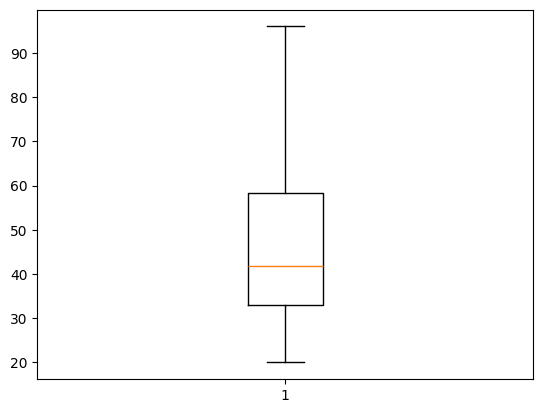

In [1162]:
plt.boxplot(median_per_book, showfliers=False)
plt.show()

In [1163]:
np.corrcoef(median_per_book, avg_per_book)

array([[1.       , 0.9186081],
       [0.9186081, 1.       ]])

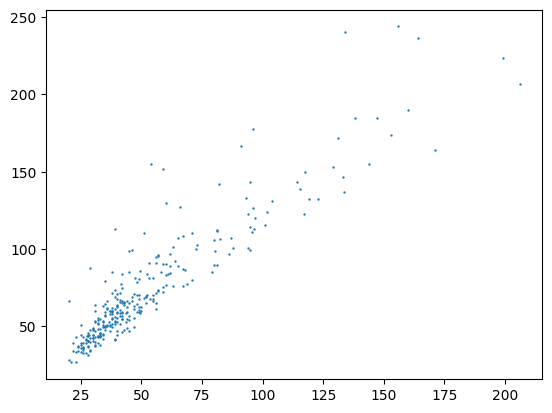

In [1164]:
plt.scatter(median_per_book, avg_per_book, s=0.5)
plt.show()

In [1165]:
np.where(np.array(len_processed[298]) == 4)

(array([ 285,  445,  676,  708,  755,  761, 1000, 1024, 1103, 1125]),)

In [1166]:
all_processed[298][211]["paragraph"]

"'Oh, you dear novelists!' he said, and shook a finger at her."

In [1151]:
print(common_pile_dataset["text"][298])

Produced by Audrey Longhurst, Mary Meehan and the Online Distributed
Proofreading Team.





                                POTTERISM

                          A TRAGI-FARCICAL TRACT

                             BY ROSE MACAULAY

                        Author of 'What Not,' etc.

                                  1920




TO THE UNSENTIMENTAL PRECISIANS IN THOUGHT, WHO HAVE, ON THIS CONFUSED,
INACCURATE, AND EMOTIONAL PLANET, NO FIT HABITATION


'They contract a Habit of talking loosely and confusedly.'--J. CLARKE.


'My dear friend, clear your mind of cant.... Don't _think_ foolishly.'
SAMUEL JOHNSON.


'On the whole we are
Not intelligent--
No, no, no, not intelligent.'--W.S. GILBERT.


'Truth may perhaps come to the price of a Pearle, that sheweth best by
day; But it will not rise to the price of a Diamond or Carbuncle, that
sheweth best in varied lights. A mixture of a Lie doth ever adde
Pleasure. Doth any man doubt, that if there were taken out of men's
mindes Vaine Opinions, 

In [314]:
re.search(r'^[A-Z ]{2,}\.{0,1}$', "THE CAT.")

<re.Match object; span=(0, 8), match='THE CAT.'>

In [319]:
PATTERN_3_MORE_SPACE = re.compile(r"\s+")

In [320]:
paragraphs = re.sub(PATTERN_3_MORE_SPACE, " ", "This is a     test  example")

In [321]:
paragraphs

'This is a test example'

In [2]:
ls ../data/interim/

metadata_ids.csv    paragraphs.parquet


In [4]:
paragraphs = load_dataset("parquet", data_files = "../data/interim/paragraphs.parquet")

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [5]:
paragraphs

DatasetDict({
    train: Dataset({
        features: ['paragraphs', 'text_ids', 'spans', 'chapters'],
        num_rows: 24950946
    })
})

In [24]:
def compute_length(samples):
    result = {"n_words":[]}
    for sample in samples["paragraphs"]:
        result["n_words"].append(len(sample.split()))
        
    return result

In [25]:
all_lengths = paragraphs["train"].map(compute_length, batched=True, batch_size=128, num_proc=2)

Map (num_proc=2):   0%|          | 0/24950946 [00:00<?, ? examples/s]

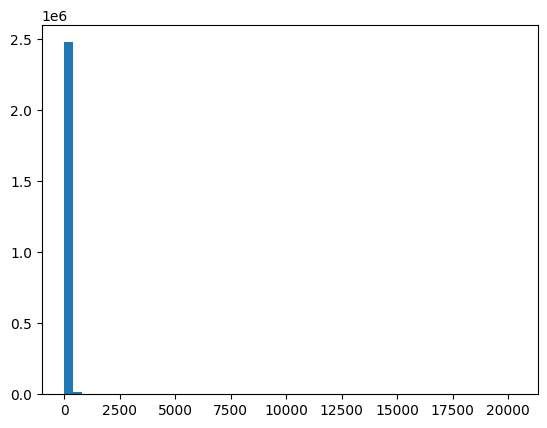

In [36]:
plt.hist(all_lengths["n_words"][::10], bins=50)
plt.show()

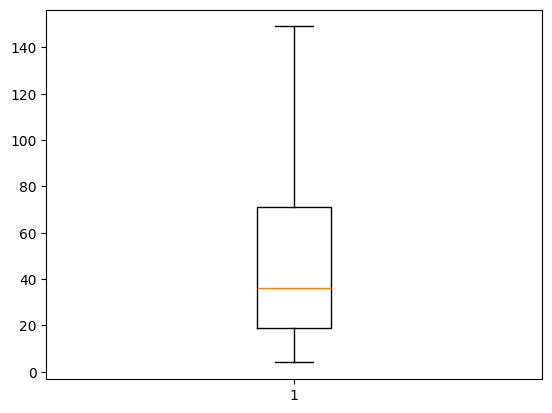

In [41]:
plt.boxplot(all_lengths["n_words"][::1], showfliers=False)
plt.show()

In [111]:
to_sort = all_lengths.select_columns(["n_words", "text_ids"]).to_pandas()

In [114]:
to_sort.iloc[15022501]

n_words     77602
text_ids    49875
Name: 15022501, dtype: int64

In [232]:
to_sort.sort_values("n_words", ascending=False).head(15950)

,n_words,text_ids
15022501,77602,49875
17901024,40642,56742
17605698,36987,56070
17779509,36605,56502
15236216,27167,50422
...,...,...
8109436,829,3440
14953766,829,4969
18296631,829,57724
1536936,829,15474


In [110]:
to_sort

,n_words,text_ids
0,15,10005
1,22,10005
2,21,10005
3,20,10005
4,31,10005
...,...,...
24950941,17,9988
24950942,22,9988
24950943,47,9988
24950944,54,9988


In [177]:
to_sort.iloc[15641454]

n_words      8725
text_ids    51357
Name: 15641454, dtype: int64

In [170]:
all_ids = np.array([eval(i) for i in common_pile_dataset["id"]])

def print_paragraph(paragraph_id):
    print(all_lengths[paragraph_id]["paragraphs"])
    
def print_original_text(text_id):
    indx = np.where(all_ids == text_id)
    print(common_pile_dataset[indx]["text"][0])
    
    
def print_paragraph_and_original(paragraph_id):
    print_paragraph(paragraph_id)
    print("\n\n\n")
    print("DONE")
    print_original_text(to_sort.iloc[paragraph_id]["text_ids"])
    

In [175]:
all_lengths[15641454]["paragraphs"].split(".")

['And ',
 '',
 '',
 ' there shall or may be from henceforth for ever in all and every convenient and needful place and places of our kingdom of England and dominion of Wales one or more honest sufficient and skilful person or persons of the said art or mystery which shall be and shall be called the deputy or deputies of the Master Wardens and Assistants of the said Corporation art or mystery, to be from time to time hereafter elected nominated and appointed by the said Master Wardens and Assistants or four of them, whereof the Master and one of the Wardens of the said corporation art or mystery for the time being to be always two, and to continue in the place or places of deputy or deputies of the Master Wardens and Assistants of the said corporation art or mystery for the time being from the time of their said election for the space of one whole year next ensuing or until he be for some just cause removed and some other of the said corporation art or mystery be elected nominated and s

In [172]:
print_paragraph_and_original(15641454)

And ... there shall or may be from henceforth for ever in all and every convenient and needful place and places of our kingdom of England and dominion of Wales one or more honest sufficient and skilful person or persons of the said art or mystery which shall be and shall be called the deputy or deputies of the Master Wardens and Assistants of the said Corporation art or mystery, to be from time to time hereafter elected nominated and appointed by the said Master Wardens and Assistants or four of them, whereof the Master and one of the Wardens of the said corporation art or mystery for the time being to be always two, and to continue in the place or places of deputy or deputies of the Master Wardens and Assistants of the said corporation art or mystery for the time being from the time of their said election for the space of one whole year next ensuing or until he be for some just cause removed and some other of the said corporation art or mystery be elected nominated and sworn to the sa

In [163]:
print_original_text(text_id = 63111)

Produced by Brian Coe, Karin Spence, The book cover image
was created by the transcriber and is placed in the public
domain. and the Online Distributed Proofreading Team at
https://www.pgdp.net (This book was created from images
of public domain material made available by the University
of Toronto Libraries
(http://link.library.utoronto.ca/booksonline/).)









                         THE GRENADIER GUARDS
                          IN THE GREAT WAR OF
                               1914-1918




  [Illustration]

                      MACMILLAN AND CO., LIMITED

                  LONDON · BOMBAY · CALCUTTA · MADRAS
                               MELBOURNE

                         THE MACMILLAN COMPANY

                      NEW YORK · BOSTON · CHICAGO
                        DALLAS · SAN FRANCISCO

                   THE MACMILLAN CO. OF CANADA, LTD.

                                TORONTO

  [Illustration:

    _Speaight Ltd photographers_      _Emery Walker ph. sc._

  _Captain 

In [164]:
print_paragraph(20158703)

16125 Abbott, E. W. 20947 Abbott, J. 24805 Abbotts, J. 29017 Abery, E. S. F. 17894 Abram, F. C. 26566 Abram, L. 9628 Ace, T. 14095 Acres, J. J. 17312 Adams, E. G. 15610 Adams, G. 9774 Adams, W. H. 10170 Adby, W. 14758 Adey, C. A. 28672 Admans, A. H. 23368 Adnitt, R. F. 20338 Alder, A. E. 22486 Alder, A. F. 24371 Alderson, R., M.M. 15232 Aldridge, H. 15976 Alesbury, F. 14804 Alexander, A. R. 23652 Alexander, G. 16332 Allen, A. W. 17700 Allen, E. R. 21888 Allen, E. T. 17159 Allen, F. 18543 Allen, J. 14650 Allen, W. G. 18298 Allen, W. G. 30117 Allen, W. H. 21425 Allerston, J. T. 18521 Allin, W. F. 29093 Allison, T. R. 11452 Allman, F. 18878 Allport, E. H. 18480 Allsopp, J. 25665 Almond, W. 30483 Amos, W. S. E. 33690 Amos, W. 27601 Amsbury, D. P. J. 25414 Anderson, W. A. 29300 Andrews, A. 14422 Andrews, A. J. 20289 Andrews, E. 23184 Andrews, H. S. 18727 Andrews, J. C. 25322 Angus, W. A. 16165 Antill, H. 13737 Anthony, W. 19215 Appleby, E. F. 14215 Apps, W. 30582 Archer, H. G. 18254 Armison

In [129]:
all_lengths[17901023]

{'paragraphs': 'N. B. In this Index the Cities are printed in Capitals, as BATH; the Boroughs and Market Towns in small Capitals, as =Dorchester=; and every other Place, or object in print, as Bagshot.',
 'text_ids': 56742,
 'spans': [142014, 142199],
 'chapters': 'END OF INDEX TO THE COUNTRY SEATS.',
 'n_words': 33}

In [227]:
np.percentile(all_lengths["n_words"][::10], 99.9)

KeyboardInterrupt: 

In [229]:
len(all_lengths["n_words"])*0.001

24950.946

In [46]:
np.mean(all_lengths["n_words"][::1])

59.44019312935069

In [51]:
np.argmax(all_lengths["n_words"])

15022501

In [55]:
mask = all_lengths["text_ids"] == 49875

In [86]:
all_lengths[15022501]["paragraphs"]

"|NAME. |REGTL.| DATE OF|DATE OF |HIGHEST |HONOURS | | NO.|JOINING.|LEAVING WITH |RANK. |OR | | | |CAUSE. | |AWARDS. | | | | | | |Abbey, H. | 2407| 11/9/14|5/8/15, |Rifleman. | | | | |transferred | | | | | | | | |Ackroyd, E. | 2954|12/11/14|12/1/15, |Rifleman. | | | | |transferred | | | | | | | | |Ackroyd, E. | 1600| 23/2/15|26/6/15, |Rifleman. | | | | |transferred | | | | | | | | |Acton, E. | 3037|16/11/14|16/2/16, |Rifleman. | | | | |transferred | | | | | | | | |Adams, A. R. |241017|11/11/14|3/10/18, |Sergeant. | | | | |wounded | | | | | | | | |Adams, B. C. | 2097| 31/8/14|26/6/15, |Rifleman. | | | | |transferred | | | | | | | | |Adams, C. | 2732| 2/11/14|12/1/15, |Rifleman. | | | | |transferred | | | | | | | | |Adams, C. |243663| 6/10/16|21/1/19,† |L./Corpl. | | | | |demobilized | | | | | | | | |Adams, E. C. | 2116| 31/8/14|13/11/14, |Rifleman. | | | | |commission | | | | | | | | |Adams, H. | 2481| 11/9/14|5/8/15, |Rifleman. | | | | |transferred | | | | | | | | |Adams, J. H. |242348

In [71]:
all_lengths[51]

{'paragraphs': 'Nor was this all. In a deep sequestered nook, formed by two spurs of this mountain, there lived a venerable Hindoo, whom the people of the village called the Holy Hermit. The favourable accounts I received of his character, as well as his odd course of life, made me very desirous of becoming acquainted with him; and, as he was often visited by the villagers, I found no difficulty in getting a conductor to his cell. His character for sanctity, together with a venerable beard, might have discouraged advances towards an acquaintance, if his lively piercing eye, a countenance expressive of great mildness and kindness of disposition, and his courteous manners, had not yet more strongly invited it. He was indeed not averse to society, though he had seemed thus to fly from it; and was so great a favourite with his neighbours, that his cell would have been thronged with visitors, but for the difficulty of the approach to it. As it was, it was seldom resorted to, except for the 

In [77]:
common_pile_dataset[np.where(common_pile_dataset["id"] == "49875")]

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/603902591.py:1: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  common_pile_dataset[np.where(common_pile_dataset["id"] == "49875")]


TypeError: only length-1 arrays can be converted to Python scalars

In [83]:
print(common_pile_dataset["text"][43034])

Produced by Richard Tonsing, Brian Coe and the Online
Distributed Proofreading Team at http://www.pgdp.net







THE HISTORY

OF THE

2/6th (RIFLE) BATTALION "THE KING'S"

(LIVERPOOL REGIMENT)

1914-1919

[Illustration: Photo by Houghton, Margate.

LIEUT.-COL. W. A. L. FLETCHER, D.S.O.]




THE HISTORY

_of the_

2/6th (Rifle) Battalion "The King's"

(Liverpool Regiment)

1914-1919


_BY_
CAPT. C. E. WURTZBURG, M.C.
_Adjutant, Nov. 1916-Nov. 1918_

WITH A FOREWORD BY
MAJOR-GENERAL SIR R. W. R. BARNES, K.C.B., D.S.O.
_Late G.O.C. 57th (West Lancs.) Division_

PRINTED FOR THE REGIMENTAL COMMITTEE

BY
GALE & POLDEN LIMITED
WELLINGTON WORKS, ALDERSHOT
1920

To the Memory

OF

LIEUT.-COL. W. A. L. FLETCHER, D.S.O.

THE OFFICERS

WARRANT OFFICERS

NON-COMMISSIONED OFFICERS

AND

RIFLEMEN

WHO LAID DOWN THEIR LIVES

FOR THEIR

COUNTRY

    _Not fearing death, nor shrinking for distress,
    But always resolute in most extremes._




FOREWORD


As I had the honour of commanding the 57th (West

In [78]:
np.where(common_pile_dataset["id"] == "49875")

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/3313166723.py:1: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  np.where(common_pile_dataset["id"] == "49875")


(array([], dtype=int64),)

In [80]:
t = [eval(i) for i in common_pile_dataset["id"]]

In [82]:
np.where(np.array(t) == 49875)

(array([43034]),)

In [181]:
catalog[(catalog[["Text#"]].values == 43629)[:, 0]].Bookshelves.values

array(['Category: Short Stories; Category: Mythology, Legends & Folklore'],
      dtype=object)

In [182]:
to_sort

,n_words,text_ids
0,15,10005
1,22,10005
2,21,10005
3,20,10005
4,31,10005
...,...,...
24950941,17,9988
24950942,22,9988
24950943,47,9988
24950944,54,9988


In [184]:
.apply(get_bookshelves)

SyntaxError: invalid syntax (3287824833.py, line 1)

In [187]:
all_text_ids = set(to_sort.text_ids.values)

In [192]:
kept_ids = catalog[catalog["Text#"].isin(all_text_ids)]
kept_ids.Bookshelves_bag_of_words = kept_ids.Bookshelves.apply(get_bookshelves)

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/2543898620.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  kept_ids.Bookshelves_bag_of_words = kept_ids.Bookshelves.apply(get_bookshelves)


In [195]:
genre_to_keep = set(['novels',
         'britishliterature',
         'adventure',
         'americanliterature',
         'children',
         'youngadultreading',
         'sciencefiction',
         'biographies',
         'historyamerican',
         'historymodern(1750+)', 
         'fantasy',
         'shortstories',
         'historicalnovels',
         'historybritish',
         'travelwriting',
         'historywarfare',
         'historyother',
         'folklore',
         'mythology',
         'legends', 
         'historyeuropean', 
         'romance',
         'crime',
         'thrillersandmystery',
         'historyearlymodern(c.14501750)',
         'frenchliterature',
         'classicsofliterature'])

for col in genre_to_keep:
    kept_ids[col] = 0

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/3933066087.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kept_ids[col] = 0
/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/3933066087.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kept_ids[col] = 0
/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/3933066087.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [200]:
def check_if_history(t):
    for c in t:
        if "history" in c:
            return 1
        
    return 0

In [189]:
def check_if_in_bookshelf(list_shelves):
    for col in list_shelves

23649

In [193]:
kept_ids.Bookshelves_bag_of_words

20       [mythology, legends, folklore, classicsofliter...
23                            [novels, americanliterature]
26                             [novels, britishliterature]
56       [historicalnovels, adventure, mythology, legen...
63       [sciencefiction, sciencefiction, fantasy, adve...
                               ...                        
73430               [historybritish, historymodern(1750+)]
73431                    [sciencefiction, fantasy, novels]
73432           [shortstories, crime, thrillersandmystery]
73438                 [crime, thrillersandmystery, novels]
73439                                  [adventure, novels]
Name: Bookshelves, Length: 23649, dtype: object

In [196]:
kept_ids

,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves,historicalnovels,...,children,frenchliterature,travelwriting,biographies,romance,britishliterature,crime,historyeuropean,classicsofliterature,fantasy
20,21,Text,2008-06-25,Three hundred Aesop’s fables\r\nTranslated by ...,en,"Aesop, 621? BCE-565? BCE; Townsend, George Fyl...","Fables, Greek -- Translations into English; Ae...",PA; PZ,"Category: Mythology, Legends & Folklore; Categ...",0,...,0,0,0,0,0,0,0,0,0,0
23,24,Text,2008-06-27,O Pioneers!,en,"Cather, Willa, 1873-1947",Nebraska -- Fiction; Historical fiction; Front...,PS,Category: Novels; Category: American Literature,0,...,0,0,0,0,0,0,0,0,0,0
26,27,Text,1992-03-01,Far from the Madding Crowd,en,"Hardy, Thomas, 1840-1928",Didactic fiction; Love stories; Triangles (Int...,PR,Category: Novels; Category: British Literature,0,...,0,0,0,0,0,0,0,0,0,0
56,57,Text,1993-03-01,Aladdin and the Magic Lamp,en,Unknown,Fairy tales; Children's stories; Arabs -- Folk...,PZ,Category: Historical Novels; Category: Adventu...,0,...,0,0,0,0,0,0,0,0,0,0
63,64,Text,1993-05-01,The gods of Mars,en,"Burroughs, Edgar Rice, 1875-1950",Science fiction; Mars (Planet) -- Fiction; Lif...,PS,Science Fiction; Category: Science-Fiction & F...,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73430,73610,Text,2024-05-12,Sketches of social life in India,en,"Buckland, C. T. (Charles Thomas), 1824-1894",India -- Social life and customs; British -- I...,DA; DS,Category: History - British; Category: History...,0,...,0,0,0,0,0,0,0,0,0,0
73431,73611,Text,2024-05-12,The life-masters,en,"Hamilton, Edmond, 1904-1977; Rankin, Hugh, 187...",Science fiction; Horror tales; Life -- Fiction,PS,Category: Science-Fiction & Fantasy; Category:...,0,...,0,0,0,0,0,0,0,0,0,0
73432,73612,Text,2024-05-12,The murderer,en,"Leinster, Murray, 1896-1975; Senf, C. C. (Curt...",Short stories; Murderers -- Fiction,PS,"Category: Short Stories; Category: Crime, Thri...",0,...,0,0,0,0,0,0,0,0,0,0
73438,73618,Text,2024-05-13,Splashes of red,en,"Davis, J. Frank (James Francis), 1870-1942",Short stories; Detective and mystery stories; ...,PS,"Category: Crime, Thrillers and Mystery; Catego...",0,...,0,0,0,0,0,0,0,0,0,0


In [205]:
kept_ids["is_history"] = kept_ids.Bookshelves_bag_of_words.apply(check_if_history)

/var/folders/6m/46qftl4j0kjcyvy_lh05f3_w00ztgk/T/ipykernel_93308/4238751516.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kept_ids["is_history"] = kept_ids.Bookshelves_bag_of_words.apply(check_if_history)


In [216]:
result_history = pd.merge(left= to_sort, right=kept_ids[kept_ids["is_history"]==1], left_on=["text_ids"], right_on=["Text#"], how="inner")

In [222]:
result_not_history = pd.merge(left= to_sort, right=kept_ids[kept_ids["is_history"]==0], left_on=["text_ids"], right_on=["Text#"], how="inner")

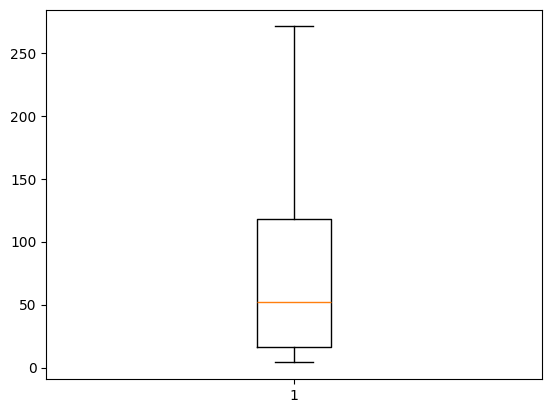

In [221]:
plt.boxplot(result_history.n_words, showfliers=False)
plt.show()

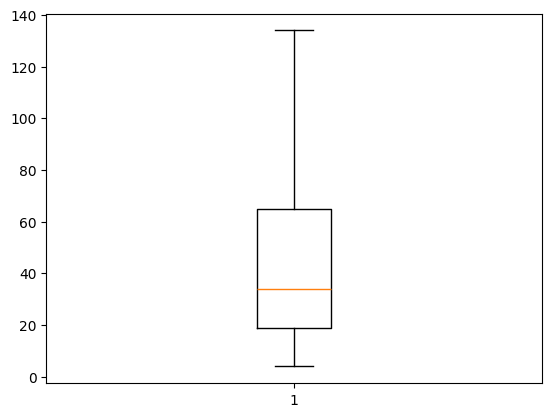

In [223]:
plt.boxplot(result_not_history.n_words, showfliers=False)
plt.show()

In [211]:
kept_ids["Text#"].iloc[0]

21

In [4]:
import numpy as np
a = np.zeros(3)
a[0] = "a"

ValueError: could not convert string to float: 'a'

In [473]:
type([]) == list()

False

In [7]:
uv pip install nltk

/Users/gabdu45/opt/miniconda3/envs/cryodrgn35/bin/python3.12: No module named uv
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
from nltk.tokenize import sent_tokenize

In [143]:
from datasets import Dataset

In [ ]:
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


In [3]:
paragraphs = load_dataset("parquet", data_files = "../data/interim/paragraphs.parquet", split="train")

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [425]:
def split_paragraph(paragraph: str, max_p_length: int) -> list[str]:
    """
    Splits a paragraph in as many needed to be smaller than the maximum length.
    :param paragraphs: content of the paragraph.
    :param max_p_length: maximum size of the paragraph.
    return at least one paragraph (if unchanged) or more (if needed to break)
    """
    all_subparagraphs = []
    sentences = sent_tokenize(paragraph)
    agg_sentences = []
    length_sentence = 0
    for sentence_number, sent in enumerate(sentences):
        words = sent.split()
        length_sent = len(words)
        length_sentence += length_sent
        if length_sentence > max_p_length and sentence_number > 0:
            all_subparagraphs.append(" ".join(agg_sentences))
            agg_sentences = [sent]
            length_sentence = length_sent
            continue
        
        agg_sentences.append(sent)
    
    all_subparagraphs.append(" ".join(agg_sentences))
    
    return all_subparagraphs
            
            
def break_paragraphs(paragraphs: str, max_p_length: int) -> str:
    """
    This function breaks paragraphs that are too big.
    :param paragraphs: content of the paragraph.
    :param max_p_length: maximum size of the paragraph.
    return at least one paragraph (if unchanged) or more (if needed to break)
    """
    index = paragraphs["index"]
    chapters = paragraphs["chapters"]
    spans = paragraphs["spans"]
    text_ids = paragraphs["text_ids"]
    indexes = paragraphs["index"]
    paragraphs = paragraphs["paragraphs"] 
    splitted_paragraphs_data = {"paragraphs":[], "n_words":[], "paragraph_index":[], "text_ids":[], 
                               "spans":[], "chapters":[], "index":[], "splitted_paragraphs":[]}
    for num_p, p in enumerate(paragraphs):
        all_words = p.split()
        length_p = len(all_words)
        if length_p < max_p_length:
            splitted_paragraphs_data["paragraphs"].append(p)
            splitted_paragraphs_data["n_words"].append(length_p)
            splitted_paragraphs_data["text_ids"].append(text_ids[num_p])
            splitted_paragraphs_data["spans"].append(spans[num_p])
            splitted_paragraphs_data["chapters"].append(chapters[num_p])
            splitted_paragraphs_data["index"].append(index[num_p])
            splitted_paragraphs_data["paragraph_index"].append(indexes[num_p])
            splitted_paragraphs_data["splitted_paragraphs"].append(False)
        else:
            number_of_cuts = length_p // max_p_length
            rest_of_cuts = length_p % max_p_length
            if rest_of_cuts > 0:
                number_of_cuts += 1
                
            splitted_paragraphs = split_paragraph(p, max_p_length/number_of_cuts)
            len_paragraphs = [len(p.split()) for p in splitted_paragraphs]
            splitted_paragraphs_data["paragraphs"] += splitted_paragraphs
            splitted_paragraphs_data["n_words"] += len_paragraphs
            splitted_paragraphs_data["paragraph_index"] += [indexes[num_p]]*len(len_paragraphs)
            splitted_paragraphs_data["text_ids"] += [text_ids[num_p]]*len(len_paragraphs)
            splitted_paragraphs_data["spans"] += [spans[num_p]]*len(len_paragraphs)
            splitted_paragraphs_data["chapters"] += [chapters[num_p]]*len(len_paragraphs)
            splitted_paragraphs_data["index"] += [index[num_p]]*len(len_paragraphs)
            splitted_paragraphs_data["splitted_paragraphs"] += [True]*len(len_paragraphs)
            
            
    return splitted_paragraphs_data
        

def update_data(current_text: str, current_length: int, text_id: int, chapter: str, span_start: int, span_stop: int, data: dict)-> None:
    """
    Updates the dictionnary data with the values provided in the arguments
    """
    data["paragraphs"].append(current_text)
    data["n_words"].append(current_length)
    data["text_ids"].append(text_id)
    data["chapters"].append(chapter)
    data["spans"].append((span_start, span_stop))
    
def reset():
    """
    Reset values to None, None, "", 0
    """
    return None, None, "", 0
    
    
def aggregate_paragraphs(hf_dataset: Dataset, threshold_min: int) -> Dataset:
    """
    Function that aggregates the paragraphs with sliding windows to get the context and a minimal amount
    of words for each aggregate.
    :param hf_dataset, the dataset to aggregate. Should have at least rows ["text_ids", "index", "paragraphs", "n_words"]
    :param threshold_min: integer, minimum number of words in the paragraph.
    """
    data = {col_num:[] for col_num in hf_dataset.features.keys() if col_num != "paragraph_index"}
    current_length = 0
    current_text = ""
    #For each paragraph, if the total length paragraph is not up to threshold, add it.
    text_id = None
    paragraph_id = None
    chapter = None
    span_start = None
    span_stop = None
    for paragraph in tqdm(hf_dataset):
        text_id_new = paragraph["text_ids"]
        paragraph_id_new = paragraph["paragraph_index"]
        chapter_new = paragraph["chapters"]
        if span_start is None:
            span_start = paragraph["spans"][0]
        
        span_stop = paragraph["spans"][1]
        current_length += paragraph["n_words"]
        current_text = "\n\n".join([current_text, paragraph["paragraphs"]])
        if ((text_id == text_id_new or text_id is None) and ((paragraph_id_new - 1) == paragraph_id or paragraph_id is None) and (chapter == chapter_new)):
            if current_length >=threshold_min:
                update_data(current_text, current_length, text_id, chapter, span_start, span_stop, data)
                span_start, span_stop, current_text, current_length = reset()
                
        else:
            #Here we are in the case where the paragraphs do not follow each other or same chapter or same book
            #In that case we need to save the current text in the data, and start the processing of a new text. 
            update_data(current_text, current_length, text_id, chapter, span_start, span_stop, data)
            if  paragraph["n_words"]>=threshold_min:
                update_data(paragraph["paragraphs"], paragraph["n_words"], text_id_new, chapter_new, span_start, span_stop, data)
                span_start, span_stop, current_text, current_length = reset()
            else:
                current_length += paragraph["n_words"]
                current_text = "\n\n".join([current_text, paragraph["paragraphs"]])
                
                
            #current_length = paragraph["n_words"]
            #current_text = paragraph["paragraphs"]
            #span_start = paragraph["spans"][0]
            #span_stop = paragraph["spans"][1]
            
            
            
        chapter = chapter_new
        text_id = text_id_new
        paragraph_id = paragraph_id_new
            
    return data




def aggregate_paragraphs2(hf_dataset: Dataset, threshold_min: int) -> Dataset:
    """
    Function that aggregates the paragraphs with sliding windows to get the context and a minimal amount
    of words for each aggregate.
    :param hf_dataset, the dataset to aggregate. Should have at least rows ["text_ids", "index", "paragraphs", "n_words"]
    :param threshold_min: integer, minimum number of words in the paragraph.
    """
    data = {col_num:[] for col_num in hf_dataset.features.keys() if col_num != "paragraph_index"}
    current_length = 0
    current_text = ""
    #For each paragraph, if the total length paragraph is not up to threshold, add it.
    text_id = None
    paragraph_id = None
    chapter = None
    span_start = None
    span_stop = None
    for paragraph in tqdm(hf_dataset):
        text_id_new = paragraph["text_ids"]
        paragraph_id_new = paragraph["paragraph_index"]
        chapter_new = paragraph["chapters"]
        text_new = paragraph["paragraphs"]
        length_new = paragraph["n_words"]
        if ((text_id != text_id_new and text_id is not None) or 
            ((paragraph_id_new - 1) != paragraph_id and paragraph_id is not None) or 
            (chapter != chapter_new)):
            if current_text != "":
                update_data(current_text, current_length, text_id, chapter, span_start, span_stop, data)
                span_start, span_stop, current_text, current_length = reset()
            if length_new >= threshold_min:
                update_data(text_new, length_new, text_id_new, chapter_new, span_start, span_stop, data)
            else:
                current_text = current_text = "\n\n".join([current_text, paragraph["paragraphs"]])
                current_length += length_new
                text_id = text_id_new
                paragraph_id = paragraph_id_new
                chapter = chapter_new
     
        else:
            current_text = current_text = "\n\n".join([current_text, paragraph["paragraphs"]])
            current_length += length_new
            text_id = text_id_new
            paragraph_id = paragraph_id_new
            chapter = chapter_new
            if current_length >= threshold_min:
                update_data(current_text, current_length, text_id, chapter, span_start, span_stop, data)
                span_start, span_stop, current_text, current_length = reset()
            
                
    return data

In [147]:
paragraphs = paragraphs.rename_column("index", "paragraph_index")

In [152]:
paragraphs = paragraphs.map(lambda x: {"n_words":[len(y.split()) for y in x["paragraphs"]]}, 
                            batch_size=256, batched = True, num_proc=16)

Map (num_proc=16):   0%|          | 0/24950946 [00:00<?, ? examples/s]

In [255]:
paragraphs_aggregated = aggregate_paragraphs(Dataset.from_dict(paragraphs[:40]), 40)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 11827.43it/s]


In [426]:
paragraphs_aggregated = aggregate_paragraphs2(Dataset.from_dict(paragraphs[:100000]), 40)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 17826.21it/s]


In [428]:
len(Dataset.from_dict(paragraphs_aggregated)[0]["paragraphs"].split())

37

In [334]:
Dataset.from_dict(paragraphs_aggregated)[2]

{'paragraphs': "The Brahmin's illness--He reveals an important secret to Atterley--Curious information concerning the Moon--The Glonglims--They plan a voyage to the Moon.",
 'text_ids': 10005,
 'spans': [634, 1049],
 'chapters': 'CHAPTER II',
 'n_words': 20}

In [462]:
Dataset.from_dict(paragraphs_aggregated)[52:60]

{'paragraphs': ['\n\n_The Brahmin\'s illness--He reveals an important secret to Atterley-- Curious information concerning the Moon--The Glonglims--They plan a voyage to the Moon._\n\nAbout this period, one afternoon in the month of March, when I repaired to the hermitage as usual, I found my venerable friend stretched on his humble pallet, breathing very quickly, and seemingly in great pain. He was labouring under a pleurisy, which is not unfrequent in the mountainous region, at this season. He told me that his disease had not yielded to the ordinary remedies which he had tried when he first felt its approach, and that he considered himself to be dangerously ill. "I am, however," he added, "prepared to die. Sit down on that block, and listen to what I shall say to you. Though I shall quit this state of being for another and a better, I confess that I was alarmed at the thought of expiring, before I had an opportunity of seeing and conversing with you. I am the depository of a secret, t

In [464]:
paragraphs[57:70]

{'paragraphs': ["_The Brahmin's illness--He reveals an important secret to Atterley-- Curious information concerning the Moon--The Glonglims--They plan a voyage to the Moon._",
  'About this period, one afternoon in the month of March, when I repaired to the hermitage as usual, I found my venerable friend stretched on his humble pallet, breathing very quickly, and seemingly in great pain. He was labouring under a pleurisy, which is not unfrequent in the mountainous region, at this season. He told me that his disease had not yielded to the ordinary remedies which he had tried when he first felt its approach, and that he considered himself to be dangerously ill. "I am, however," he added, "prepared to die. Sit down on that block, and listen to what I shall say to you. Though I shall quit this state of being for another and a better, I confess that I was alarmed at the thought of expiring, before I had an opportunity of seeing and conversing with you. I am the depository of a secret, that

In [439]:
20 + 21 + 22 + 23 + 24

110

In [247]:
paragraphs_aggregated["chapters"][:100]

[None,
 'CHAPTER I',
 'CHAPTER II',
 'CHAPTER III',
 'CHAPTER IV',
 'CHAPTER V',
 'CHAPTER VI',
 'CHAPTER VII',
 'CHAPTER VIII',
 'CHAPTER IX',
 'CHAPTER X',
 'CHAPTER XI',
 'CHAPTER XII',
 'CHAPTER XIII',
 'CHAPTER XIV',
 'CHAPTER XV',
 'CHAPTER XVI',
 'CHAPTER XVII',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'APPEAL TO THE PUBLIC.',
 'CHAPTER I',
 'CHAPTER I',
 'CHAPTER I',
 'CHAPTER I']

In [259]:
paragraphs_aggregated["n_words"]

[37,
 19,
 214,
 272,
 160,
 97,
 89,
 73,
 116,
 208,
 41,
 107,
 88,
 72,
 60,
 225,
 188,
 140]

In [263]:
paragraphs["paragraphs"][:5]

['Produced by Christine De Ryck, Stig M. Valstad, Suzanne L. Shell and PG Distributed Proofreaders',
 '"It is the very error of the moon, She comes more near the earth than she was wont, And makes men mad."--_Othello_.',
 "Atterley's birth and education--He makes a voyage-- Founders off the Burman coast--Adventures in that Empire--Meets with a learned Brahmin from Benares.",
 "The Brahmin's illness--He reveals an important secret to Atterley--Curious information concerning the Moon--The Glonglims--They plan a voyage to the Moon.",
 "The Brahmin and Atterley prepare for their voyage-- Description of their travelling machine--Incidents of the voyage--The appearance of the earth; Africa; Greece--The Brahmin's speculations on the different races of men--National character."]

In [257]:
paragraphs_aggregated["paragraphs"][:40]

['\n\nProduced by Christine De Ryck, Stig M. Valstad, Suzanne L. Shell and PG Distributed Proofreaders\n\n"It is the very error of the moon, She comes more near the earth than she was wont, And makes men mad."--_Othello_.',
 '\n\nAppendix: Anonymous Review of _A Voyage to the Moon,_ reprinted from _The American Quarterly Review_ No. 5 (March 1828)',
 '\n\nOn my return to this my native State, as soon as it was noised abroad that I had met with extraordinary adventures, and made a most wonderful voyage, crowds of people pressed eagerly to see me. I at first met their inquiries with a cautious silence, which, however, but sharpened their curiosity. At length I was visited by a near relation, with whom I felt less disposed to reserve. With friendly solicitude he inquired "how much I had made by my voyage;" and when he was informed that, although I had added to my knowledge, I had not improved my fortune, he stared at me a while, and remarking that he had business at the Bank, as well as a

In [246]:
paragraphs_aggregated = aggregate_paragraphs(Dataset.from_dict(paragraphs[:40]), 40)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 6808.66it/s]

None 10005
None 0
None None


10005 10005
0 1
None None


10005 10005
1 2
None CHAPTER I


10005 10005
2 3
CHAPTER I CHAPTER II


10005 10005
3 4
CHAPTER II CHAPTER III


10005 10005
4 5
CHAPTER III CHAPTER IV


10005 10005
5 6
CHAPTER IV CHAPTER V


10005 10005
6 7
CHAPTER V CHAPTER VI


10005 10005
7 8
CHAPTER VI CHAPTER VII


10005 10005
8 9
CHAPTER VII CHAPTER VIII


10005 10005
9 10
CHAPTER VIII CHAPTER IX


10005 10005
10 11
CHAPTER IX CHAPTER X


10005 10005
11 12
CHAPTER X CHAPTER XI


10005 10005
12 13
CHAPTER XI CHAPTER XII


10005 10005
13 14
CHAPTER XII CHAPTER XIII


10005 10005
14 15
CHAPTER XIII CHAPTER XIV


10005 10005
15 16
CHAPTER XIV CHAPTER XV


10005 10005
16 17
CHAPTER XV CHAPTER XVI


10005 10005
17 18
CHAPTER XVI CHAPTER XVII


10005 10005
18 19
CHAPTER XVII CHAPTER XVII


10005 10005
19 20
CHAPTER XVII APPEAL TO THE PUBLIC.


10005 10005
20 21
APPEAL TO THE PUBLIC. APPEAL TO THE PUBLIC.


10005 10005
21 22
APPEAL TO THE PUBLIC. APPEAL TO THE PUBLIC.


10005 10

In [229]:
np.where(np.array(paragraphs_aggregated["n_words"]) == 0)

(array([1, 2, 3, 4, 5, 6, 7]),)

In [230]:
len(paragraphs[:1000]["paragraphs"][2].split())

21

In [231]:
paragraphs_aggregated["paragraphs"]

['\n\nProduced by Christine De Ryck, Stig M. Valstad, Suzanne L. Shell and PG Distributed Proofreaders\n\n"It is the very error of the moon, She comes more near the earth than she was wont, And makes men mad."--_Othello_.',
 '',
 '',
 '',
 '',
 '',
 '',
 '']

In [223]:
len("""\n\nProduced by Christine De Ryck, Stig M. Valstad, Suzanne L. Shell and PG Distributed 
Proofreaders\n\n"It is the very error of the moon, She comes more near the earth than she was wont, 
And makes men mad."--_Othello_.""".split())

37

In [179]:
paragraphs_aggregated

In [176]:
paragraphs.features.keys()

dict_keys(['paragraphs', 'text_ids', 'spans', 'chapters', 'paragraph_index', 'n_words'])

In [155]:
all_lens = []
for length in tqdm(paragraphs["n_words"]):
    all_lens.append(length)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24950946/24950946 [13:46<00:00, 30188.61it/s]


In [159]:
np.where(np.array(all_lens) == 4)

(array([     630,      782,      810, ..., 24950107, 24950385, 24950766]),)

In [162]:
paragraphs[810]

{'paragraphs': 'Congdon was sent for.',
 'text_ids': 10008,
 'spans': [37766, 37787],
 'chapters': 'THE SECOND PRIZE CREW',
 'paragraph_index': 810,
 'n_words': 4}

In [146]:
aggregate_paragraphs(paragraphs)

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'index'],
    num_rows: 24950946
})

In [145]:
paragraphs

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'index'],
    num_rows: 24950946
})

In [6]:
paragraphs = paragraphs.map(lambda batch, idx: {"index": idx}, with_indices=True, batched=True, num_proc=16, 
                            batch_size=256)

Map (num_proc=16):   0%|          | 0/24950946 [00:00<?, ? examples/s]

In [75]:
p = paragraphs.map(break_paragraphs, num_proc=16, batched=True, batch_size=256, 
               remove_columns=["paragraphs"], fn_kwargs={"max_p_length":1000})

Map (num_proc=16):   0%|          | 0/24950946 [00:00<?, ? examples/s]

In [79]:
p

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'index', 'n_words', 'paragraph_index', 'splitted_paragraphs'],
    num_rows: 25000020
})

In [81]:
p = p.sort(["text_ids", "index"])

In [109]:
p["text_ids"][:718]

[21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,


In [117]:
p["index"][718]

4308247

In [77]:
p_splitted = p.filter(lambda x: x["splitted_paragraphs"] == True)

Filter:   0%|          | 0/25000020 [00:00<?, ? examples/s]

In [64]:
[len(x) for x in p_splitted[2:5]["paragraphs"]]

[5470, 5378, 175]

In [70]:
len(p_splitted[3]["paragraphs"].split())

976

In [72]:
len(p_splitted[4]["paragraphs"].split())

30

In [62]:
len(paragraphs[616]["paragraphs"].split())

1999

In [53]:
len(p_splitted["paragraphs"][2:4])

2

In [55]:
len(" ".join(p_splitted["paragraphs"][2:4]).split())

1969

In [30]:
paragraphs_71609.filter(lambda x: x["spans"] == [565892, 641799])["paragraphs"]

Column(['2038 Abbey O, Cor 174 - June 15 64 2141 Abbey W H 85 E June 18 4719 Abel C Art 15 C Aug 4 4612 Aber J 104 I Aug 3 5626 Ackerman Saml 97 K Aug 14 64 Ackheart David 20 A Mar 19 8497 Adams H 98 G Sept 11 4581 Adams J A 10 F Aug 2 6467 Adams O 61 C Aug 22 8559 Adams S, S’t 100 - Sept 12 3226 Adams T R 85 H July 12 1700 Ades Ed Cav 8 C June 7 5047 Adeler A 8 D Aug 8 6575 Adney F 85 K Aug 23 4382 Ahearn Daniel 170 - July 31 3349 Aiken J W 85 H July 15 8001 Akerman M Art 7 L Sept 6 7062 Albarson J 42 C Aug 28 6698 Albert Wm Bat 24 - Aug 24 7007 Alderman F Cav 15 F Aug 27 1755 Alexander J 125 C June 9 11212 Alford B C 152 F Oct 20 3293 Allen A W Art 14 - July 14 12452 Allen J I 82 A Jan 14 65 5568 Allen W Cav 1 H Aug 13 64 5844 Allenburger J 39 B Aug 16 7478 Allenberens E 39 D Sept 1 11497 Allinger L 48 I Oct 26 7587 Allman Chas Art 7 C Sept 2 6941 Almy F 111 K Aug 26 5938 Alphord J 75 G Aug 17 7739 Alsaver S 47 H Sept 3 800 Ambler Fred 47 H Apr 29 2344 Ambrose Jacob C 2 C June 23 106

In [133]:
l = []
for k in tqdm(p["n_words"]):
    l.append(k)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25000020/25000020 [17:06<00:00, 24362.36it/s]


In [139]:
l = []
for k in tqdm(paragraphs["n_words"]):
    l.append(k)

ValueError: Column 'n_words' doesn't exist.

In [134]:
sorted_l = sorted(l)

In [135]:
sorted_l

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


In [136]:
l = np.array(l)
np.where(l==1)

(array([ 1397192,  1398013,  4001553,  4002341,  8709141,  8709276,
         8709313, 16775190, 16775287, 16775435, 16775480, 16775655,
        16776516, 16776572, 16776964, 16777221, 16777643, 16778259,
        16778329, 16778693, 16778745, 16778947, 16779041, 16779095,
        16779201, 16779868, 16779932, 16780106, 16780347, 16780420,
        16780722, 19099704, 19462386, 20172910, 20382751, 20715790]),)

In [137]:
p["n_words"][1397192]

1

In [138]:
p["paragraphs"][1397192]

'20s.'

In [20]:
max(l)

17123

In [19]:
24962230/24950946

1.0004522473817226

In [14]:
paragraphs

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters'],
    num_rows: 24950946
})

In [121]:
np.max(p["n_words"])

KeyboardInterrupt: 

In [20]:
help(datasets.Dataset.map)

Help on function map in module datasets.arrow_dataset:

map(self, function: Optional[Callable] = None, with_indices: bool = False, with_rank: bool = False, input_columns: Union[str, list[str], NoneType] = None, batched: bool = False, batch_size: Optional[int] = 1000, drop_last_batch: bool = False, remove_columns: Union[str, list[str], NoneType] = None, keep_in_memory: bool = False, load_from_cache_file: Optional[bool] = None, cache_file_name: Optional[str] = None, writer_batch_size: Optional[int] = 1000, features: Optional[datasets.features.features.Features] = None, disable_nullable: bool = False, fn_kwargs: Optional[dict] = None, num_proc: Optional[int] = None, suffix_template: str = '_{rank:05d}_of_{num_proc:05d}', new_fingerprint: Optional[str] = None, desc: Optional[str] = None, try_original_type: Optional[bool] = True, on_mixed_types: Optional[Literal['use_json']] = 'use_json') -> 'Dataset'
    Apply a function to all the examples in the table (individually or in batches) and upd

In [120]:
p.features.keys()

dict_keys(['paragraphs', 'text_ids', 'spans', 'chapters', 'index', 'n_words', 'paragraph_index', 'splitted_paragraphs'])

In [467]:
dict_data = {"paragraphs":["This is a test paragraphs.",
                           "and another one",
                           "yet another one",
                           "another small one",
                           "a very very very very very very very very very very long paragraph."
                           "another small paragraph.",
                           "but with an skipped paragraph id."
                           ],
             "chapters":["I", "I", "II", "II", "II", "III", "III"],
             "n_words":[5, 3, 3, 3, 13, 3, 6],
             "text_ids":[0, 0, 1, 1, 1, 2, 2],
             "paragraph_index":[0, 1, 3,4,5, 14, 16],
             "spans":[(0, 10), (14, 35), (10, 14), (14, 28), (35, 67), (18, 24), (36, 45)]}

In [469]:
len(dict_data["paragraphs"])

6

In [474]:
d = {"a":3}

In [477]:
d.get("b", 1)

1

In [478]:
16*256

4096